# Big Analysis

## Import dependencies

In [32]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.base import ClassifierMixin
from sklearn.tree import plot_tree

Code fetchen und mit dem kombinieren was karan bisher gemacht hat

## Load dataset

In [14]:
df_spotify = pd.read_csv("../data/spotify.csv")

In [15]:
df_spotify.head()

,id,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 1. Data Preparation & Target Definition

In [16]:
# Drop text-based and identifier columns not used for audio feature prediction
cols_to_drop_text = ['track_id', 'artists', 'album_name', 'track_name']
df_spotify = df_spotify.drop(columns=cols_to_drop_text, errors='ignore')

# Handle the single row with missing values 
df_spotify = df_spotify.dropna()

# TARGET VARIABLE CREATION
# Map 'popularity' >= 70 to 'is_hit' (1) and everything else to 0
df_spotify['is_hit'] = (df_spotify['popularity'] >= 70).astype(int)
df_spotify = df_spotify.drop('popularity', axis=1) # Drop the original continuous target

# FEATURE ENGINEERING
# Convert track length from milliseconds to seconds for better interpretation
df_spotify['duration_s'] = df_spotify['duration_ms'] / 1000.0
df_spotify = df_spotify.drop('duration_ms', axis=1) # Drop the original ms column

print("\n'is_hit' Distribution:")
print(df_spotify['is_hit'].value_counts(normalize=True))


'is_hit' Distribution:
is_hit
0    0.952
1    0.048
Name: proportion, dtype: float64


### Data Preparation & Target Definition Findings

After importing and cleaning the Spotify dataset, the target variable **`popularity`** was converted into a binary classification variable **`is_hit`**. A song is considered a Hit (**1**) if its popularity is $\geq 70$; otherwise, it is classified as a Non-Hit (**0**).

#### Finding: Extreme Class Imbalance

The analysis of the target variable reveals an **extreme class imbalance**. This is the central challenge for modeling and requires special techniques (such as `class_weight='balanced'` or `scale_pos_weight`).

| Class | Share | Description |
| :--- | :--- | :--- |
| **0 (Non-Hit)** | $95.2\%$ | The dominant majority class. |
| **1 (Hit)** | $4.8\%$ | The rare minority class that we aim to predict. |

## 2. Feature Encoding and Scaling Preparation

In [17]:
df_model_clean = df_spotify.drop(columns=['id'])

# Separate features (X) and target (y)
X = df_model_clean.drop('is_hit', axis=1)
y = df_model_clean['is_hit']

# Define categorical and continuous columns for the next step (Encoding/Scaling)
categorical_cols = ['explicit', 'key', 'mode', 'time_signature', 'track_genre']
continuous_cols = [col for col in X.columns if col not in categorical_cols]

# ENCODING CATEGORICAL FEATURES 
X_encoded_base = pd.get_dummies(X.copy(), columns=categorical_cols, drop_first=True)

# Data split (80% Train, 20% Test)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_encoded_base, y, test_size=0.2, random_state=42, stratify=y
)

# SCALING CONTINUOUS FEATURES
scaler_base = StandardScaler()
X_train_base[continuous_cols] = scaler_base.fit_transform(X_train_base[continuous_cols])
X_test_base[continuous_cols] = scaler_base.transform(X_test_base[continuous_cols])

print("Original (Base) Data Set created: X_train_base, X_test_base")

Original (Base) Data Set created: X_train_base, X_test_base


In [18]:
def create_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates and adds new acoustic ratio and interaction features to the DataFrame."""
    
    # Copy the DataFrame to avoid SettingWithCopyWarning
    X_new = df.copy() 
    
    # Ratios (Avoid division by zero by adding 1e-6)
    
    if 'energy' in X_new.columns and 'acousticness' in X_new.columns:
        X_new['Energy_over_Acousticness'] = X_new['energy'] / (X_new['acousticness'] + 1e-6)

    if 'danceability' in X_new.columns and 'tempo' in X_new.columns:
        X_new['Danceability_over_Tempo'] = X_new['danceability'] / (X_new['tempo'] + 1e-6)

    # Interactions (Products)
    
    if 'loudness' in X_new.columns and 'energy' in X_new.columns:
        X_new['Loudness_x_Energy'] = X_new['loudness'] * X_new['energy']
        
    if 'valence' in X_new.columns and 'danceability' in X_new.columns:
        X_new['Valence_x_Danceability'] = X_new['valence'] * X_new['danceability']

    # Binary Transformation
    
    if 'loudness' in X_new.columns:
        X_new['Loudness_is_Very_High'] = (X_new['loudness'] > -3).astype(int)

    return X_new

# Re-execute create_ratio_features on a fresh copy of X
X_eng = create_ratio_features(X.copy()) # X is the original unencoded feature set

# Update continuous columns list (Assuming continuous_cols is redefined for clarity)
categorical_cols_eng = ['explicit', 'key', 'mode', 'time_signature', 'track_genre']
continuous_cols_eng = [col for col in X_eng.columns if col not in categorical_cols_eng]

# ENCODING CATEGORICAL FEATURES
X_encoded_eng = pd.get_dummies(X_eng, columns=categorical_cols_eng, drop_first=True)

# Data split (80% Train, 20% Test)
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_encoded_eng, y, test_size=0.2, random_state=42, stratify=y
)

# SCALING CONTINUOUS FEATURES
scaler_eng = StandardScaler()
X_train_eng[continuous_cols_eng] = scaler_eng.fit_transform(X_train_eng[continuous_cols_eng])
X_test_eng[continuous_cols_eng] = scaler_eng.transform(X_test_eng[continuous_cols_eng])

print("Engineered Data Set created: X_train_eng, X_test_eng")

Engineered Data Set created: X_train_eng, X_test_eng


### 2.1 Feature Processing

* **Encoding:** Categorical features (`explicit`, `key`, `mode`, `time_signature`, `track_genre`) were transformed using **One-Hot Encoding (OHE)** to convert them into a numerical format suitable for machine learning models.
* **Scaling:** Continuous audio features (e.g., `tempo`, `loudness`, `danceability`) were **Standard Scaled**. This ensures all continuous features contribute equally to the distance calculation and prevents features with larger numerical ranges from dominating the model.

### 2.2 Data Split & Stratification

The final dataset was split into an **80% training set** and a **20% testing set**.

* **Stratification Definition:** Stratification is a data sampling technique used during the train/test split to ensure that the **proportion of the target variable (classes)** in the resulting test set is the same as in the original dataset.
* **Importance in this Context:** Given the **extreme class imbalance** ($95.2\%$ Non-Hit vs. $4.8\%$ Hit), using `stratify=y` is **critical**. Without it, there is a high risk that the **minority class (Hits)** could be underrepresented or even completely missing from the smaller test set, making reliable model evaluation impossible.

### 2.3 Feature Enhancement & Dataset Creation Strategy

To robustly evaluate the impact of non-linear features, the data processing pipeline was executed twice, resulting in two distinct, stratified datasets:

1.  **Base Dataset (`_base`):** This dataset uses only the **original** scaled continuous features, OHE categories, and is used to establish the baseline performance of all models.

2.  **Engineered Dataset (`_eng`):** This dataset is enriched with **new proportional and interaction features** before encoding and scaling. These engineered features (e.g., `Energy_over_Acousticness`, `Loudness_x_Energy`) are specifically designed to capture non-linear relationships and dependencies identified during the Exploratory Data Analysis (EDA). This dataset is used to train and test the final, optimized models.

This methodology allows for a **direct, clean comparison** to isolate the performance gain attributable solely to the **Feature Engineering effort**.

## 3. Model Training and Feature Importance

### 3.1 Helper Functions to Save Results of Models

In [ ]:
# Metric extraction helper function
def extract_metrics(y_true, y_pred, model_name):
    """Extracts Precision, Recall, and F1-Score for Class '1' (Hit) from the Classification Report."""
    # classification_report is used to calculate all metrics simultaneously.
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # Focus on minority class “1” (hit)
    class_1_metrics = report['1']
    
    return {
        'Model': model_name,
        'F1-Score (Hit)': class_1_metrics['f1-score'],
        'Precision (Hit)': class_1_metrics['precision'],
        'Recall (Hit)': class_1_metrics['recall'],
        'Support (Hit)': class_1_metrics['support']
    }

# Feature Importance Helper Function
def extract_feature_importance_all(model: ClassifierMixin, X_data: pd.DataFrame) -> pd.Series:
    """
    Extracts, normalizes, and returns ALL feature importance scores, 
    sorted in descending order, for a given classifier model.
    
    Args:
        model: The trained classifier model (e.g., RandomForestClassifier, LGBMClassifier).
        X_data: The DataFrame used for training/testing (to get column names).
        
    Returns:
        A pandas Series of all normalized feature importance scores, sorted.
    """
    # Extract raw importance scores
    raw_importance = pd.Series(model.feature_importances_, index=X_data.columns)
    
    # Normalize scores
    if raw_importance.sum() == 0:
        # Avoid division by zero
        normalized_importance = raw_importance 
    else:
        normalized_importance = raw_importance / raw_importance.sum()
        
    # Return all scores, sorted by importance (descending)
    return normalized_importance.sort_values(ascending=False)

### 3.1.1 Metrics Focus: Why Class 'Hit' (1) and not Overall?

In this project, we focus exclusively on the metrics of the **minority class 'Hit' (1)** for the following reasons:

1.  **Extreme Class Imbalance:** The 'No Hit' class (0) accounts for **95.2%** of the dataset.
2.  **Misleading Overall Accuracy:** A model could achieve an overall accuracy of over $95\%$ by predicting **all songs as 'No Hit'**. This high number would be **misleading** and would obscure the model's inability to recognize actual hits.
3.  **True Performance Indicator:** **Precision (Hit), Recall (Hit)**, and the **F1-Score (Hit)** evaluate the model's ability to correctly identify the **rare but critical class**. Therefore, the F1-Score of the Hit class is the true indicator of the classifier's success in solving the actual task.

### 3.1.2 Final Metric Selection: Maximizing the Balanced F1-Score

The choice of which Class 1 metric to maximize is dependent on the business or domain goal:

* **Prioritizing Recall (Completeness):** In certain high-stakes domains, such as medical diagnostics (e.g., screening X-rays for potential cancer), the primary objective is to ensure that **every single positive case is found**, even at the cost of high False Positives. In such cases, **Recall** is prioritized.
* **Prioritizing Precision (Accuracy):** If the cost of False Positives is extremely high (e.g., stopping an entire production line due to a faulty prediction), **Precision** is prioritized.

In the context of the Spotify Hit Prediction, we do not face high-stakes consequences that necessitate prioritizing absolute completeness (Recall). Our goal is to find a model that is both **reasonably complete** and **sufficiently accurate**. Therefore, the focus is on maximizing the **F1-Score (Hit)**, which represents the harmonic mean, providing a balanced measure of performance.

### 3.2 Comparison of Models

#### Model Selection Rationale

The selection of **Logistic Regression, Random Forest, and LightGBM** was strategic, ensuring a robust comparison across different algorithmic complexities and model families. This approach allows us to determine the optimal balance between **accuracy and interpretability** for predicting Spotify hits (imbalanced binary classification).

#### Rationale for Model Selection in Audio Classification

| Model | Algorithm Family | Rationale for Selection | Suitability for Domain |
| :--- | :--- | :--- | :--- |
| **Logistic Regression (LogReg)** | Linear Model (Baseline) | Provides a fast, highly **interpretable** linear baseline. Essential for determining if a simple, additive relationship among audio features (e.g., higher 'loudness' adds to hit probability) is sufficient. | **Baseline & Interpretability:** Serves as the simplest benchmark against which non-linear models must justify their complexity. |
| **Random Forest (RF)** | Ensemble Tree (Bagging) | A robust, non-linear ensemble model. Excellent at handling complex, non-linear feature relationships and provides reliable, stable **Feature Importance** scores, which is crucial for feature analysis. | **Non-linearity & Stability:** Capable of capturing intricate feature interactions (e.g., 'high energy' combined with a specific 'genre'). Stable against noisy data. |
| **LightGBM (LGBM)** | Gradient Boosting (Boosting) | A highly efficient, state-of-the-art tree-boosting framework. Often achieves **superior accuracy** and better performance than Random Forest on structured data by iteratively correcting errors. | **Performance & Accuracy:** Represents the highest performance potential for structured audio features, often achieving the best F1-Score in competitive environments. |

#### Structured Optimization Pipeline

The analysis proceeds through the following three distinct phases for each model:

1.  **Base Model Evaluation:** The first step involves training a **Base Model** using **class weighting** to mitigate the severe class imbalance. All initial performance metrics are evaluated using the standard **default decision threshold of 0.5**. This establishes the initial performance benchmark.

2.  **Non-linear Feature Enhancement:** This phase incorporates non-linear knowledge tailored to the model family:
    * **Tree Models (RF & LGBM):** Evaluated using the **new feature-engineered dataset** (ratios and interactions like `Energy_over_Acousticness`) to enhance their predictive power.
    * **Logistic Regression (LogReg):** To enable LogReg to compete, it is trained using **polynomial features** (quadratic and interaction terms) derived from the continuous acoustic features.

3.  **Final Performance Optimization (Threshold Tuning):** The final step involves post-processing optimization. We search for the optimal decision threshold that **maximizes the F1-Score** for the minority class, correcting the prediction bias caused by the class imbalance. 

###  Why Threshold Tuning is Essential

This post-processing step clarifies the difference between optimizing the model's internal ranking and setting the final classification rule:

| Phase | Goal | Mechanism | Default Decision Boundary |
| :--- | :--- | :--- | :--- |
| **1. Training (`fit`)** | **Learn Probabilities (Ranking):** Internal parameters are adjusted (via `class_weight='balanced'` or `scale_pos_weight`) to create the best possible estimate of $P(\text{Hit})$. | Focuses on minimizing the penalty for misclassifying the minority class. | N/A (Only probability is output) |
| **2. Classification (`predict`)** | **Set Decision Boundary:** Convert the learned probability into a binary label. | The default rule is $\mathbf{P(\text{Hit}) \geq 0.5}$. | **0.5** |

#### Why the $0.5$ Default Fails in Imbalance:

1.  **Imbalance Bias:** The aggressive weighting techniques used during training (Phase 1) force the model to be extremely sensitive to the minority class. This results in **inflated estimated probabilities** for hits to avoid the high misclassification penalty.
2.  **Observed Problem:** This leads to a strong bias toward high **Recall** (finding most true hits) but a very low **Precision** (most predicted hits are False Positives).
3.  **The Fix (Post-Processing):** Threshold Tuning shifts the decision line from the ineffective default $0.5$ to a higher value (e.g., $0.785$ for LGBM, $0.583$ for RF) that provides the **optimal balance** between Precision and Recall, thereby maximizing the true F1-Score.

This methodical approach allows for a clean comparison, distinguishing the impact of **algorithmic choice**, **feature engineering**, and **bias correction** on the final prediction performance.

#### 3.2.1 Logistic Regression

##### 3.2.1.1 Logistic Regression Base Model

In [26]:
# Calculate imbalance ratio for the base data
scale_weight_base = len(y_train_base[y_train_base == 0]) / len(y_train_base[y_train_base == 1])

# Initialize the model with class weighting
logreg_base_model = LogisticRegression(
    penalty='l2', # Use L2 regularization for the base model
    solver='liblinear',
    class_weight='balanced', # Crucial for addressing class imbalance during training
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

print("\nStarting LogReg BASE Model Training (Original Features)...")
# Training using the base feature set
logreg_base_model.fit(X_train_base, y_train_base)
print("Training complete.")

# Get binary predictions using the default threshold (0.5)
y_pred_base = logreg_base_model.predict(X_test_base)

# Calculate final metrics using the helper function
logreg_base_metrics_default = extract_metrics(y_test_base, y_pred_base, 'LogReg (Base)')


# Extract coefficients (absolute values for importance)
coefficients = pd.Series(logreg_base_model.coef_[0], index=X_train_base.columns)

# Normalize the absolute coefficients to get feature importance
logreg_base_importance = np.abs(coefficients) / np.abs(coefficients).sum()

# Get the Top 15 features
logreg_base_top_15 = logreg_base_importance.nlargest(15)


print("\nFinal LogReg BASE Model Results (Default Threshold 0.5)")

# Display Feature Importance (Top 15)
print("\nTop 15 Feature Importance (Normalized Coefficients):")
print(logreg_base_top_15)

# Display Metrics
print("\nMetrics at Default Threshold (Stored in logreg_base_metrics_default):")
print(pd.Series(logreg_base_metrics_default).drop('Model'))


Starting LogReg BASE Model Training (Original Features)...


/home/simonhofer/miniconda3/envs/damin2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


Training complete.

Final LogReg BASE Model Results (Default Threshold 0.5)

Top 15 Feature Importance (Normalized Coefficients):
track_genre_kids              0.016629
track_genre_mandopop          0.016274
track_genre_j-idol            0.016245
track_genre_heavy-metal       0.016092
track_genre_goth              0.015980
track_genre_gospel            0.015817
track_genre_club              0.015804
track_genre_breakbeat         0.015783
track_genre_drum-and-bass     0.015653
track_genre_forro             0.015591
track_genre_happy             0.015529
track_genre_pop               0.015500
track_genre_mpb               0.015462
track_genre_minimal-techno    0.015248
track_genre_sertanejo         0.015067
dtype: float64

Metrics at Default Threshold (Stored in logreg_base_metrics_default):
F1-Score (Hit)     0.235845
Precision (Hit)    0.136892
Recall (Hit)       0.851005
Support (Hit)        1094.0
dtype: object


##### 3.2.1.3 Logistic Regression Quadratic Continous Features

In [ ]:
# Define continuous columns used for generating non-linear terms
logreg_continuous_features = [
    'duration_s', 'acousticness', 'energy', 'danceability', 'loudness', 'liveness', 
    'valence', 'tempo', 'speechiness', 'instrumentalness',
    # New Engineered Features (These are also used to create higher-order terms)
    'Energy_over_Acousticness', 'Danceability_over_Tempo',
    'Loudness_x_Energy', 'Valence_x_Danceability'
]

# Ensure we only use columns present in the scaled engineered data
current_continuous_cols = [col for col in logreg_continuous_features if col in X_train_eng.columns]

# Initialize PolynomialFeatures (degree=2 creates x^2 and x1*x2 terms)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Copy engineered datasets for transformation
X_train_poly_eng = X_train_eng.copy()
X_test_poly_eng = X_test_eng.copy()

# Fit on training data and transform continuous columns
X_train_poly_data = X_train_eng[current_continuous_cols]
X_train_poly_transformed = poly.fit_transform(X_train_poly_data)
poly_feature_names = poly.get_feature_names_out(X_train_poly_data.columns)

# Reconstruct training DataFrame with new polynomial features
X_train_poly_eng = X_train_poly_eng.drop(columns=current_continuous_cols)
X_train_poly_eng = pd.concat([X_train_poly_eng.reset_index(drop=True), 
                              pd.DataFrame(X_train_poly_transformed, columns=poly_feature_names)], 
                              axis=1)

# Transform test set using the fitted transformer
X_test_poly_data = X_test_eng[current_continuous_cols]
X_test_poly_transformed = poly.transform(X_test_poly_data)

# Reconstruct test DataFrame
X_test_poly_eng = X_test_poly_eng.drop(columns=current_continuous_cols)
X_test_poly_eng = pd.concat([X_test_poly_eng.reset_index(drop=True), 
                             pd.DataFrame(X_test_poly_transformed, columns=poly_feature_names)], 
                             axis=1)

print(f"Polynomial Feature Engineering complete. Total features increased to {X_train_poly_eng.shape[1]}.")

# Calculate imbalance ratio
scale_weight_eng = len(y_train_eng[y_train_eng == 0]) / len(y_train_eng[y_train_eng == 1])

# Initialize LogReg with L1 regularization (Lasso) and class weighting
# L1 regularization acts as a crucial feature selector for the many new polynomial terms.
logreg_poly_eng_model = LogisticRegression(
    penalty='l1', 
    C=0.1, # Stronger regularization (lower C)
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

print("\nStarting LogReg (Polynomial + Engineered Features) Training...")
# Training using the polynomial feature set
logreg_poly_eng_model.fit(X_train_poly_eng, y_train_eng)
print("Training complete.")

# Get binary predictions using the default threshold (0.5)
y_pred_base_poly_eng = logreg_poly_eng_model.predict(X_test_poly_eng)

# Calculate final metrics
logreg_poly_metrics_default = extract_metrics(y_test_eng, y_pred_base_poly_eng, 'LogReg (Poly + Eng)')

# Extract and normalize coefficients (Feature Importance)
coefficients = pd.Series(logreg_poly_eng_model.coef_[0], index=X_train_poly_eng.columns)
logreg_poly_importance = np.abs(coefficients) / np.abs(coefficients).sum()
logreg_poly_top_15 = logreg_poly_importance.nlargest(15)


print("\n-LogReg (Polynomial + Engineered) Results at Default Threshold 0.5")

# Display Feature Importance (Top 15)
print("\nTop 15 Feature Importance (Normalized Coefficients):")
print(logreg_poly_top_15)

# Display Final Metrics
print("\nMetrics at Default Threshold 0.5 (Stored in logreg_poly_metrics_default):")
print(pd.Series(logreg_poly_metrics_default).drop('Model'))

Polynomial Feature Engineering complete. Total features increased to 250.

Starting LogReg (Polynomial + Engineered Features) Training...


/home/simonhofer/miniconda3/envs/damin2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


Training complete.

--- LogReg (Polynomial + Engineered) Results at Default Threshold 0.5 ---

Top 15 Feature Importance (Normalized Coefficients):
track_genre_pop            0.017057
track_genre_mandopop       0.016714
track_genre_j-idol         0.015622
track_genre_metal          0.015610
track_genre_gospel         0.015595
track_genre_goth           0.015581
track_genre_kids           0.015530
track_genre_club           0.014987
track_genre_heavy-metal    0.014674
track_genre_mpb            0.014634
track_genre_indie          0.014542
track_genre_electro        0.014348
track_genre_sertanejo      0.014285
track_genre_forro          0.014265
track_genre_k-pop          0.014217
dtype: float64

Metrics at Default Threshold 0.5 (Stored in logreg_poly_metrics_default):
F1-Score (Hit)     0.243043
Precision (Hit)    0.142126
Recall (Hit)       0.838208
Support (Hit)        1094.0
dtype: object


##### 3.2.1.3 Logistic Regression Threshold Tuning


--- Final LogReg (Polynomial + Engineered) Optimization Results ---
Optimal Threshold Found: 0.7900
Metrics at Optimal Threshold (Stored in tuned_logreg_poly_metrics_optimal_eng):
F1-Score (Hit)     0.313797
Precision (Hit)    0.235564
Recall (Hit)       0.469835
Support (Hit)        1094.0
dtype: object


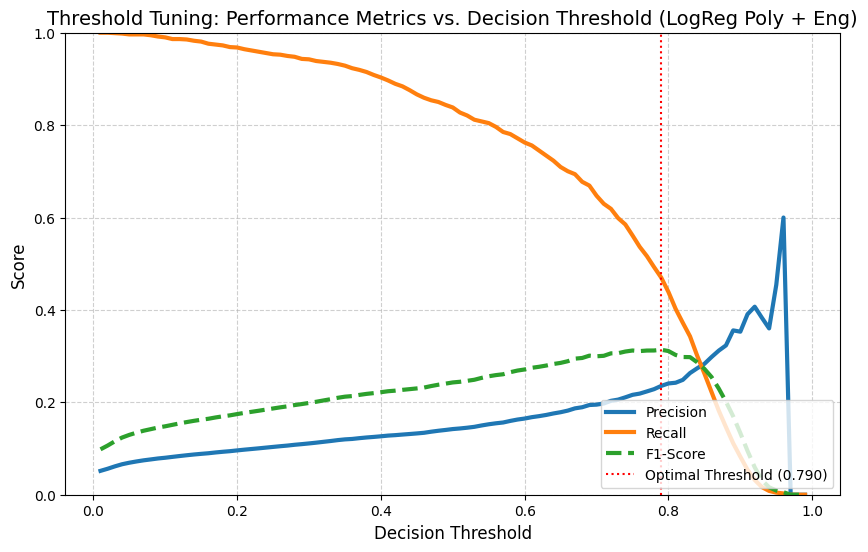

In [ ]:
# Predict probabilities for the positive class (Hit = 1)
y_proba_logreg_poly_eng = logreg_poly_eng_model.predict_proba(X_test_poly_eng)[:, 1]

# Define the range of thresholds to test
thresholds = np.arange(0.01, 1.0, 0.01)
results_poly_eng = []

# Search for the optimal threshold that maximizes the F1-Score
for t in thresholds:
    y_pred_tuned = (y_proba_logreg_poly_eng >= t).astype(int)
    
    # Calculate Precision, Recall, F1 for the minority class (1)
    precision, recall, f1, support = precision_recall_fscore_support(y_test_eng, y_pred_tuned, average=None, labels=[0, 1], zero_division=0)
    
    results_poly_eng.append({
        'Threshold': t,
        'F1-Score': f1[1],
        'Precision': precision[1],
        'Recall': recall[1]
    })

results_poly_df_eng = pd.DataFrame(results_poly_eng)

# Find optimal threshold
optimal_row_poly_eng = results_poly_df_eng.loc[results_poly_df_eng['F1-Score'].idxmax()]
optimal_threshold_poly_eng = optimal_row_poly_eng['Threshold']


# Calculate final metrics at the optimal threshold
y_pred_optimal_poly_eng = (y_proba_logreg_poly_eng >= optimal_threshold_poly_eng).astype(int)

# Assuming extract_metrics() is the helper function defined previously
tuned_logreg_poly_metrics_optimal_eng = extract_metrics(y_test_eng, y_pred_optimal_poly_eng, 'LogReg (Poly + Eng + Tuned)')


print("\n--- Final LogReg (Polynomial + Engineered) Optimization Results ---")
print(f"Optimal Threshold Found: {optimal_threshold_poly_eng:.4f}")
print("Metrics at Optimal Threshold (Stored in tuned_logreg_poly_metrics_optimal_eng):")
print(pd.Series(tuned_logreg_poly_metrics_optimal_eng).drop('Model'))

plt.figure(figsize=(10, 6))

# Plot the curves
plt.plot(results_poly_df_eng['Threshold'], results_poly_df_eng['Precision'], label='Precision', linewidth=3)
plt.plot(results_poly_df_eng['Threshold'], results_poly_df_eng['Recall'], label='Recall', linewidth=3)
plt.plot(results_poly_df_eng['Threshold'], results_poly_df_eng['F1-Score'], label='F1-Score', linewidth=3, linestyle='--')

# Draw the optimal threshold line
plt.axvline(optimal_threshold_poly_eng, color='red', linestyle=':', 
            label=f"Optimal Threshold ({optimal_threshold_poly_eng:.3f})")

# Formatting
plt.title('Threshold Tuning: Performance Metrics vs. Decision Threshold (LogReg Poly + Eng)', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.0)
plt.show()

#### 3.2.2 Random Forest

##### 3.2.2.1 Random Forest Base Model (with Hyperparameter Tuning through GirdSearch)

Starting RF GridSearch (Base Data)...
GridSearch complete.


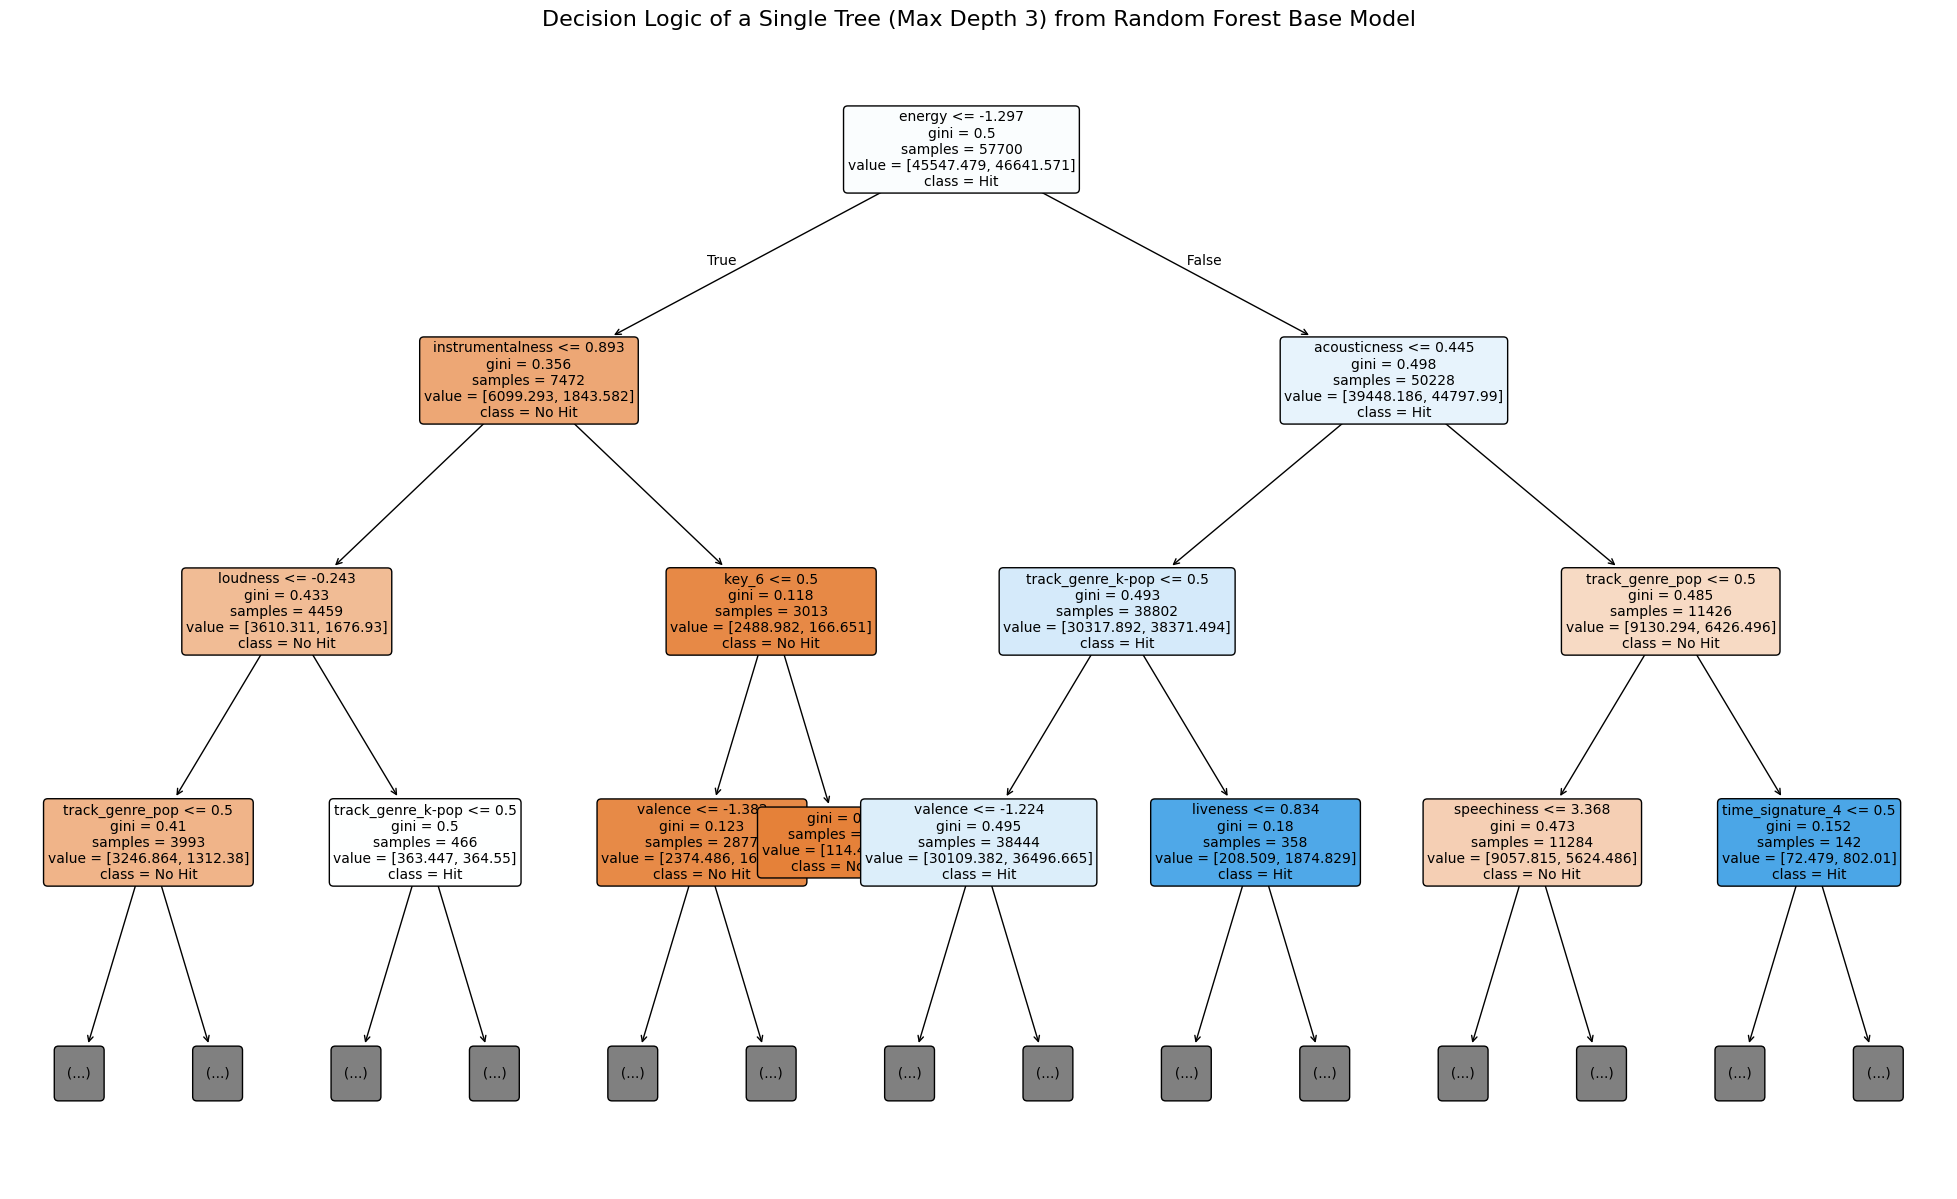


Final Random Forest BASE Model Results:
Best RF F1 Score (Base Data, Threshold 0.5): 0.2592
---

Random Forest BASE Top 15 Feature Importance Scores:
instrumentalness       0.101242
acousticness           0.074400
energy                 0.074116
loudness               0.062728
liveness               0.056437
duration_s             0.056315
danceability           0.048237
valence                0.045675
speechiness            0.040082
tempo                  0.039190
track_genre_pop        0.037044
track_genre_electro    0.020498
track_genre_metal      0.020091
track_genre_k-pop      0.019377
track_genre_dance      0.017501
dtype: float64

Model Metrics (stored in rf_base_metrics):
F1-Score (Hit)     0.259246
Precision (Hit)    0.159847
Recall (Hit)       0.685558
Support (Hit)        1094.0
dtype: object


In [ ]:
# Define parameter grid for testing 
rf_param_grid_base = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced'] # Crucial for class imbalance handling
}

# Define F1-Score (Hit) as the scoring metric (minority class)
scorer_base = make_scorer(f1_score, pos_label=1, zero_division=0)

# Use GridSearchCV, prioritizing F1-Score for the minority class
rf_grid_search_base = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid_base,
    scoring=scorer_base,
    cv=3, # 3-fold cross-validation
    verbose=0,
    n_jobs=-1 # Use all available cores for faster computation
)

# Fit the model using the BASE data
print("Starting RF GridSearch (Base Data)")
rf_grid_search_base.fit(X_train_base, y_train_base)
print("GridSearch complete.")

# Model and Prediction
rf_base_model = rf_grid_search_base.best_estimator_
y_pred_rf_base = rf_base_model.predict(X_test_base)

# Feature Importance
rf_base_importance = extract_feature_importance_all(
    model=rf_base_model, 
    X_data=X_train_base
)
rf_base_top_15 = rf_base_importance.nlargest(15)


# Metrics (Hit)
rf_base_metrics = extract_metrics(
    y_true=y_test_base, 
    y_pred=y_pred_rf_base, 
    model_name='Random Forest (Base)'
)


# Select the first tree (index 0) from the best model in the forest
tree_to_visualize = rf_base_model.estimators_[0]

plt.figure(figsize=(25, 15))
plot_tree(
    tree_to_visualize, 
    filled=True, 
    rounded=True, 
    # Use the column names from the training set for features
    feature_names=X_train_base.columns.tolist(),
    class_names=['No Hit', 'Hit'],
    max_depth=3, # Limit depth to 3 for readability
    fontsize=10
)
plt.title('Decision Logic of one Single Tree (Max Depth 3) from Random Forest Base Model', fontsize=16)
plt.show()


print("\nFinal Random Forest BASE Model Results:")
print(f"Best RF F1 Score (Base Data, Threshold 0.5): {f1_score(y_test_base, y_pred_rf_base, pos_label=1):.4f}")
print("\nRandom Forest BASE Top 15 Feature Importance Scores:")
print(rf_base_top_15)
print("\nModel Metrics (stored in rf_base_metrics):")
print(pd.Series(rf_base_metrics).drop('Model'))

##### 3.2.2.2 Random Forest Non-Linear Feature Dataset

Starting RF GridSearch (Engineered Data Set)...
GridSearchCV complete.


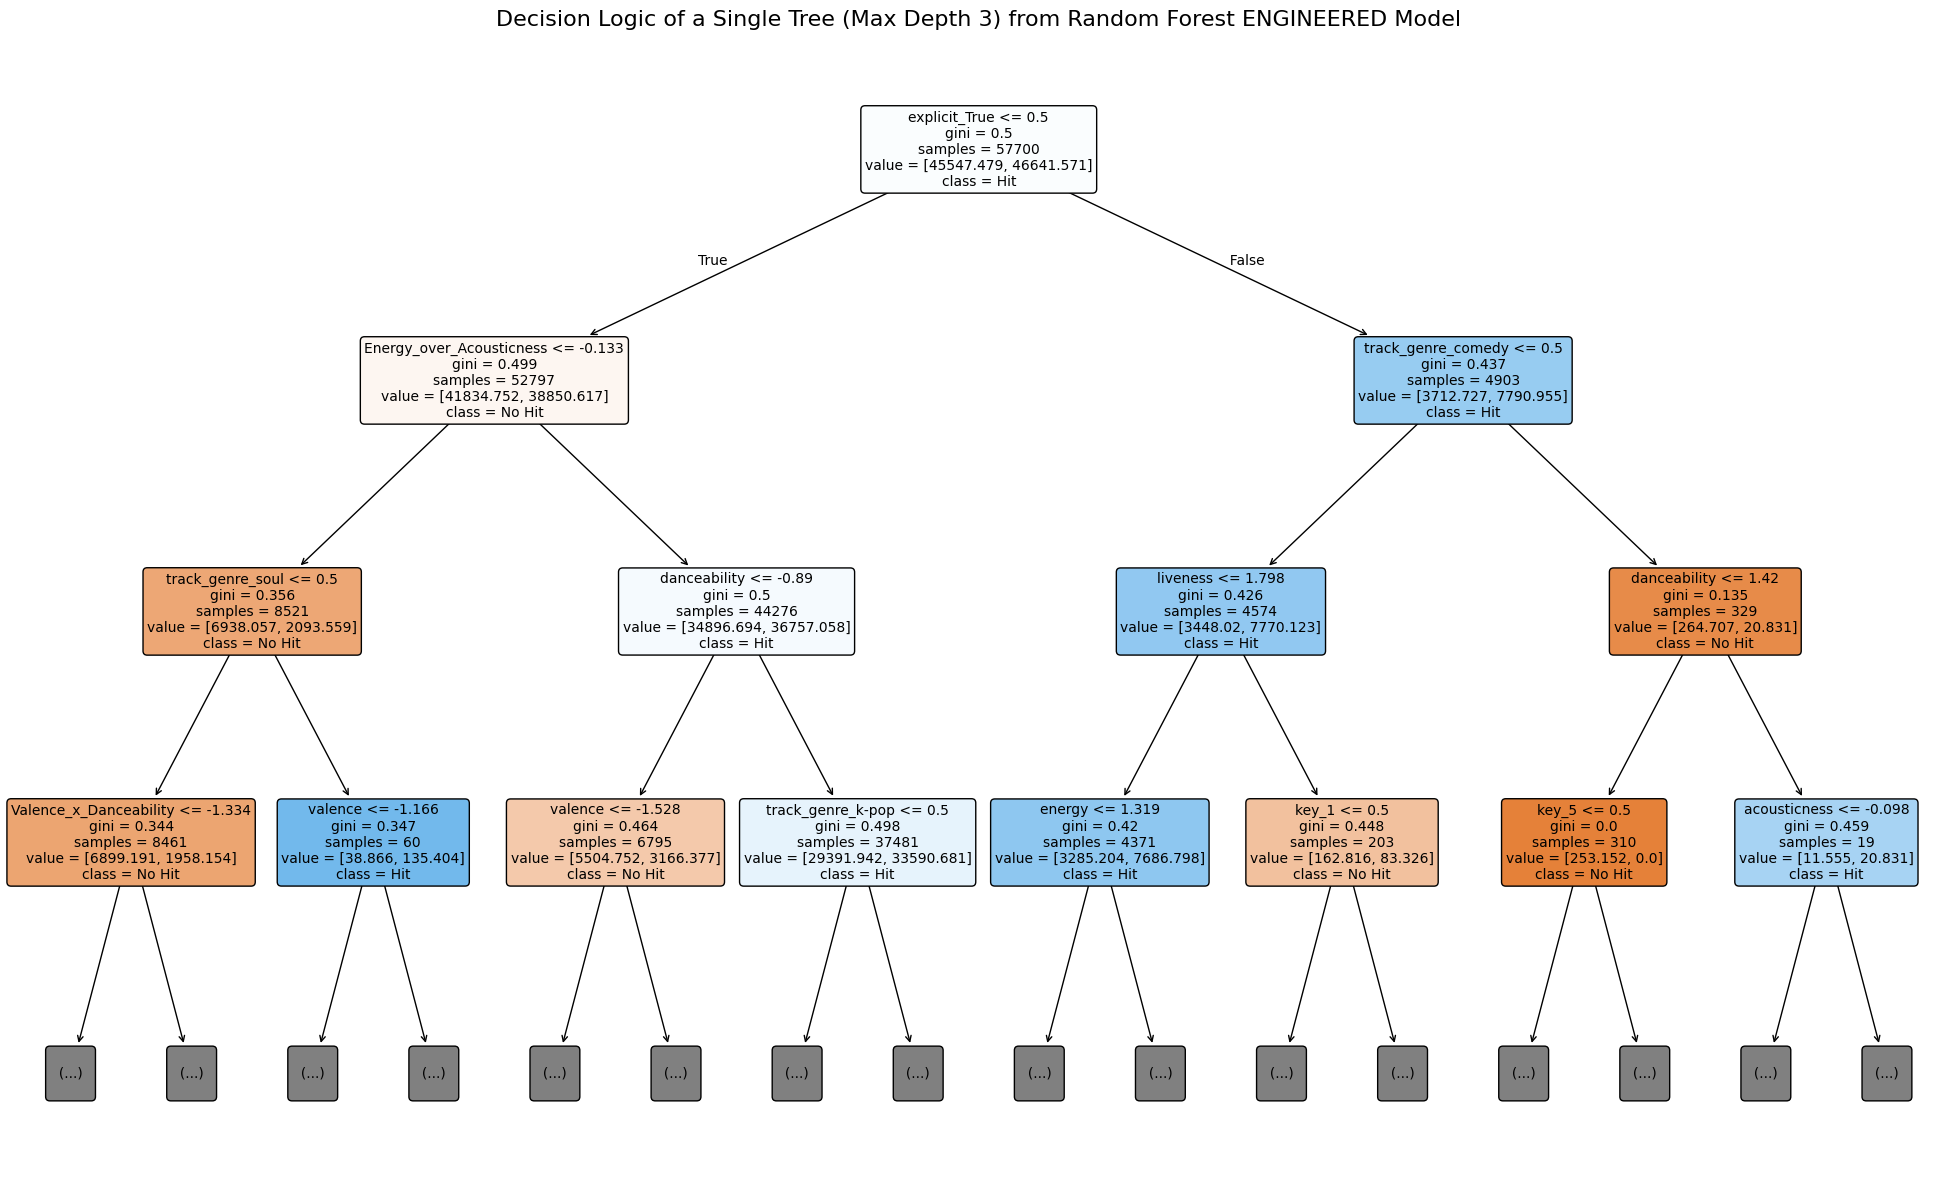


Final Random Forest ENGINEERED Model Results:
Best RF F1 Score (Engineered Data, Threshold 0.5): 0.2889
---

Random Forest ENGINEERED Top 15 Feature Importance Scores:
instrumentalness            0.088869
energy                      0.061423
acousticness                0.060418
liveness                    0.052767
Energy_over_Acousticness    0.051495
loudness                    0.049962
Loudness_x_Energy           0.049515
duration_s                  0.049113
danceability                0.040828
valence                     0.040164
Valence_x_Danceability      0.039078
Danceability_over_Tempo     0.038708
speechiness                 0.036999
tempo                       0.035730
track_genre_pop             0.027540
dtype: float64

Model Metrics (stored in rf_eng_metrics):
F1-Score (Hit)     0.288898
Precision (Hit)    0.183739
Recall (Hit)       0.675503
Support (Hit)        1094.0
dtype: object


In [ ]:
# Define parameter grid for testing (Same grid as base model)
rf_param_grid_eng = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced'] # Crucial for class imbalance handling
}

# Define F1-Score (Hit) as the scoring metric (minority class)
scorer_eng = make_scorer(f1_score, pos_label=1, zero_division=0)

# Use GridSearchCV, prioritizing F1-Score for the minority class
rf_grid_search_eng = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid_eng,
    scoring=scorer_eng,
    cv=3, # 3-fold cross-validation
    verbose=0,
    n_jobs=-1 # Use all available cores for faster computation
)

# Fit the model using the ENGINEERED data
print("Starting RF GridSearch (Engineered Data Set)")
rf_grid_search_eng.fit(X_train_eng, y_train_eng)
print("GridSearchCV complete.")

# Model and Prediction
rf_eng_model = rf_grid_search_eng.best_estimator_
y_pred_rf_eng = rf_eng_model.predict(X_test_eng)

# Feature Importance
rf_eng_importance = extract_feature_importance_all(
    model=rf_eng_model, 
    X_data=X_train_eng
)
rf_eng_top_15 = rf_eng_importance.nlargest(15)


# Metrics (Hit)
rf_eng_metrics = extract_metrics(
    y_true=y_test_eng, 
    y_pred=y_pred_rf_eng, 
    model_name='Random Forest (Engineered)'
)

# Select the first tree (index 0) from the best model in the forest
tree_to_visualize_eng = rf_eng_model.estimators_[0]

plt.figure(figsize=(25, 15))
plot_tree(
    tree_to_visualize_eng, 
    filled=True, 
    rounded=True, 
    # Use the column names from the training set for features
    feature_names=X_train_eng.columns.tolist(),
    class_names=['No Hit', 'Hit'],
    max_depth=3, # Limit depth to 3 for readability
    fontsize=10
)
plt.title('Decision Logic of one Single Tree (Max Depth 3) from Random Forest ENGINEERED Model', fontsize=16)
plt.show()


print("\nFinal Random Forest ENGINEERED Model Results:")
print(f"Best RF F1 Score (Engineered Data, Threshold 0.5): {f1_score(y_test_eng, y_pred_rf_eng, pos_label=1):.4f}")
print("\nRandom Forest ENGINEERED Top 15 Feature Importance Scores:")
print(rf_eng_top_15)
print("\nModel Metrics (stored in rf_eng_metrics):")
print(pd.Series(rf_eng_metrics).drop('Model'))

##### 3.2.2.3 Random Forest Threshold Tuning

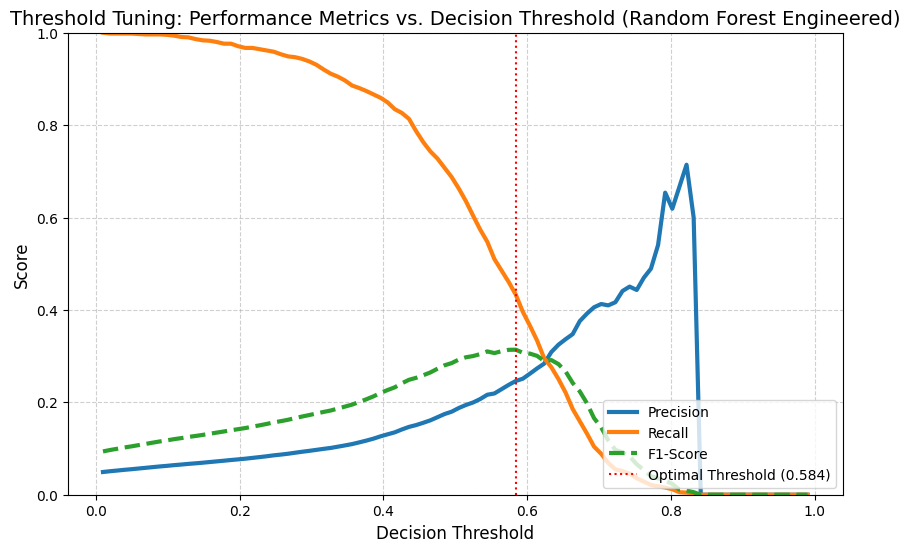


--- Random Forest (Engineered) Threshold Optimization ---
Optimal Threshold Found: 0.5841
Metrics at Optimal Threshold (Stored in tuned_rf_metrics_optimal_eng):
F1-Score (Hit)     0.313907
Precision (Hit)    0.246106
Recall (Hit)       0.433272
Support (Hit)        1094.0
dtype: object


In [ ]:
# Get probabilities for the positive class (Hit = 1) from the Engineered RF model
rf_proba_eng = rf_eng_model.predict_proba(X_test_eng)[:, 1]

# Define the range of thresholds to test (100 steps for fine search)
thresholds = np.linspace(0.01, 0.99, 100) 
rf_metric_results_eng = []

# Search for the optimal threshold that maximizes the F1-Score
for t in thresholds:
    # Generate binary predictions based on the current threshold
    y_pred_tuned_rf = (rf_proba_eng >= t).astype(int)
    
    # Calculate Precision, Recall, F1-Score for the minority class (Index 1)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_eng, 
        y_pred_tuned_rf, 
        average=None, 
        labels=[0, 1],
        zero_division=0 
    )
    
    # Store metrics for the minority class
    rf_metric_results_eng.append({
        'Threshold': t,
        'Precision': precision[1],
        'Recall': recall[1],
        'F1-Score': f1[1]
    })

rf_results_df_eng = pd.DataFrame(rf_metric_results_eng)

# Find the row with the maximum F1-Score
optimal_threshold_rf_eng = rf_results_df_eng.loc[rf_results_df_eng['F1-Score'].idxmax()]
optimal_threshold_value_eng = optimal_threshold_rf_eng['Threshold']

# Create final prediction vector using the optimal threshold
y_pred_rf_tuned_optimal_eng = (rf_proba_eng >= optimal_threshold_value_eng).astype(int)

# Calculate the final, optimized metrics using the helper function
tuned_rf_metrics_optimal_eng = extract_metrics(
    y_true=y_test_eng, 
    y_pred=y_pred_rf_tuned_optimal_eng, 
    model_name=f'RF (Eng + Tuned {optimal_threshold_value_eng:.3f})'
)

plt.figure(figsize=(10, 6))

plt.plot(rf_results_df_eng['Threshold'], rf_results_df_eng['Precision'], label='Precision', linewidth=3)
plt.plot(rf_results_df_eng['Threshold'], rf_results_df_eng['Recall'], label='Recall', linewidth=3)
plt.plot(rf_results_df_eng['Threshold'], rf_results_df_eng['F1-Score'], label='F1-Score', linewidth=3, linestyle='--')

plt.axvline(optimal_threshold_value_eng, color='red', linestyle=':', 
            label=f"Optimal Threshold ({optimal_threshold_value_eng:.3f})")

plt.title('Threshold Tuning: Performance Metrics vs. Decision Threshold (Random Forest Engineered)', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.0)
plt.show()


print("\nRandom Forest (Engineered) Threshold Optimization")
print(f"Optimal Threshold Found: {optimal_threshold_value_eng:.4f}")
print("Metrics at Optimal Threshold (Stored in tuned_rf_metrics_optimal_eng):")
print(pd.Series(tuned_rf_metrics_optimal_eng).drop('Model'))

### 3.2.3 LightGBM

##### 3.2.3.1 LightGBM Base-Model

In [52]:
# Calculate imbalance ratio: (Count of No-Hits) / (Count of Hits) for the base training data
scale_weight_base = len(y_train_base[y_train_base == 0]) / len(y_train_base[y_train_base == 1])

lgbm_base_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    # Use scale_pos_weight to handle the severe class imbalance
    scale_pos_weight=scale_weight_base, 
    random_state=42,
    n_estimators=1000, # A standard value, can be optimized later
    learning_rate=0.05,
    verbose=-1
)

print("\nStarting LightGBM BASE Model Training (Original Features)")

# Fit the model using the BASE data
lgbm_base_model.fit(X_train_base, y_train_base)

# Prediction (base threshold = 0.5)
y_pred_lgbm_base = lgbm_base_model.predict(X_test_base)


# Feature Importance
lgbm_base_importance = extract_feature_importance_all(
    model=lgbm_base_model, 
    X_data=X_train_base
)
lgbm_base_top_15 = lgbm_base_importance.nlargest(15)


# Metrics (Hit)
lgbm_base_metrics = extract_metrics(
    y_true=y_test_base, 
    y_pred=y_pred_lgbm_base, 
    model_name='LightGBM (Base)'
)


print("Training complete.")
print("\nLightGBM BASE Results")
print("\nTop 15 Feature Importance (lgbm_base_top_15) :")
print(lgbm_base_top_15)
print("\nModel Metrics (Stored in lgbm_base_metrics):")
print(pd.Series(lgbm_base_metrics).drop('Model'))


Starting LightGBM BASE Model Training (Original Features)
Training complete.

LightGBM BASE Results

Top 15 Feature Importance (lgbm_base_top_15) :
duration_s          0.085433
tempo               0.085267
loudness            0.082667
danceability        0.080900
liveness            0.077900
speechiness         0.077500
valence             0.077333
acousticness        0.076400
energy              0.074267
instrumentalness    0.054267
mode_1              0.006833
explicit_True       0.006100
key_1               0.005033
key_7               0.004367
key_5               0.003900
dtype: float64

Model Metrics (Stored in lgbm_base_metrics):
F1-Score (Hit)     0.373747
Precision (Hit)    0.248937
Recall (Hit)       0.749543
Support (Hit)        1094.0
dtype: object


#### 3.2.3.2 LightGBM Non-Linear Dataset

In [38]:
# Calculate imbalance ratio: (Count of No-Hits) / (Count of Hits) for the engineered training data
scale_weight_eng = len(y_train_eng[y_train_eng == 0]) / len(y_train_eng[y_train_eng == 1])

lgbm_eng_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    # Use scale_pos_weight to handle the severe class imbalance
    scale_pos_weight=scale_weight_eng, 
    random_state=42,
    n_estimators=1000, 
    learning_rate=0.05,
    verbose=-1
)

print("\nStarting LightGBM ENGINEERED Model Training...")

# Fit the model using the ENGINEERED data
lgbm_eng_model.fit(X_train_eng, y_train_eng)

# Prediction (base threshold = 0.5)
y_pred_lgbm_eng = lgbm_eng_model.predict(X_test_eng)

# Feature Importance
lgbm_eng_importance = extract_feature_importance_all(
    model=lgbm_eng_model, 
    X_data=X_train_eng
)
lgbm_eng_top_15 = lgbm_eng_importance.nlargest(15)


# Metrics (Hit)
lgbm_eng_metrics = extract_metrics(
    y_true=y_test_eng, 
    y_pred=y_pred_lgbm_eng, 
    model_name='LightGBM (Engineered)'
)


print("Training complete.")
print("\n--- LightGBM ENGINEERED Results ---")
print("\nTop 15 Feature Importance (lgbm_eng_top_15) :")
print(lgbm_eng_top_15)
print("\nModel Metrics (Stored in lgbm_eng_metrics):")
print(pd.Series(lgbm_eng_metrics).drop('Model'))


Starting LightGBM ENGINEERED Model Training...
Training complete.

--- LightGBM ENGINEERED Results ---

Top 15 Feature Importance (lgbm_eng_top_15) :
duration_s                  0.072433
liveness                    0.069633
speechiness                 0.067000
tempo                       0.063700
Loudness_x_Energy           0.062733
loudness                    0.057800
energy                      0.055700
Danceability_over_Tempo     0.054933
valence                     0.052833
danceability                0.050067
acousticness                0.048967
instrumentalness            0.045733
Valence_x_Danceability      0.042967
Energy_over_Acousticness    0.040033
explicit_True               0.006100
dtype: float64

Model Metrics (Stored in lgbm_eng_metrics):
F1-Score (Hit)     0.385973
Precision (Hit)    0.259905
Recall (Hit)       0.749543
Support (Hit)        1094.0
dtype: object


#### 3.2.3.3 LightGBM Threshold Tuning


LightGBM (Engineered) Threshold Optimization
Optimal Threshold Found: 0.7425
Metrics at Optimal Threshold (Stored in tuned_lgbm_metrics_optimal_eng):
F1-Score (Hit)     0.476311
Precision (Hit)    0.443307
Recall (Hit)       0.514625
Support (Hit)        1094.0
dtype: object


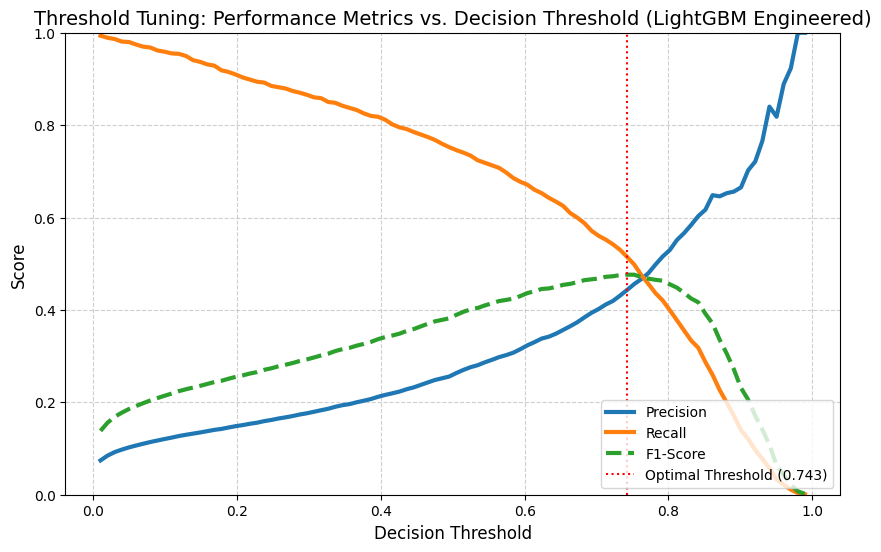

In [40]:
# Predict probabilities for the positive class (Hit = 1) from the Engineered LGBM model
y_proba_lgbm_eng = lgbm_eng_model.predict_proba(X_test_eng)[:, 1]

# Define the range of thresholds to test (100 steps for fine search)
thresholds = np.linspace(0.01, 0.99, 100) 
lgbm_metric_results_eng = []

# Search for the optimal threshold that maximizes the F1-Score
for t in thresholds:
    # Generate binary predictions based on the current threshold
    y_pred_tuned_lgbm = (y_proba_lgbm_eng >= t).astype(int)
    
    # Calculate Precision, Recall, F1-Score for the minority class (Index 1)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_eng, 
        y_pred_tuned_lgbm, 
        average=None, 
        labels=[0, 1],
        zero_division=0 
    )
    
    # Store metrics for the minority class
    lgbm_metric_results_eng.append({
        'Threshold': t,
        'Precision': precision[1],
        'Recall': recall[1],
        'F1-Score': f1[1]
    })

lgbm_results_df_eng = pd.DataFrame(lgbm_metric_results_eng)

# Find the row with the maximum F1-Score
optimal_threshold_lgbm_eng = lgbm_results_df_eng.loc[lgbm_results_df_eng['F1-Score'].idxmax()]
optimal_threshold_value_eng = optimal_threshold_lgbm_eng['Threshold']



# Create final prediction vector using the optimal threshold
y_pred_lgbm_tuned_optimal_eng = (y_proba_lgbm_eng >= optimal_threshold_value_eng).astype(int)

# Calculate the final, optimized metrics using the helper function
tuned_lgbm_metrics_optimal_eng = extract_metrics(
    y_true=y_test_eng, 
    y_pred=y_pred_lgbm_tuned_optimal_eng, 
    model_name=f'LGBM (Engineered + Tuned)'
)


print("\nLightGBM (Engineered) Threshold Optimization")
print(f"Optimal Threshold Found: {optimal_threshold_value_eng:.4f}")
print("Metrics at Optimal Threshold (Stored in tuned_lgbm_metrics_optimal_eng):")
print(pd.Series(tuned_lgbm_metrics_optimal_eng).drop('Model'))

plt.figure(figsize=(10, 6))

# Plot the curves for Precision, Recall, and F1-Score
plt.plot(lgbm_results_df_eng['Threshold'], lgbm_results_df_eng['Precision'], label='Precision', linewidth=3)
plt.plot(lgbm_results_df_eng['Threshold'], lgbm_results_df_eng['Recall'], label='Recall', linewidth=3)
plt.plot(lgbm_results_df_eng['Threshold'], lgbm_results_df_eng['F1-Score'], label='F1-Score', linewidth=3, linestyle='--')

# Draw the optimal threshold line
plt.axvline(optimal_threshold_value_eng, color='red', linestyle=':', 
            label=f"Optimal Threshold ({optimal_threshold_value_eng:.3f})")

# Formatting
plt.title('Threshold Tuning: Performance Metrics vs. Decision Threshold (LightGBM Engineered)', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.0)
plt.show()

#### 3.2.4 Model Evaluation

##### 3.2.4.1 Impact of Threashold Tuning

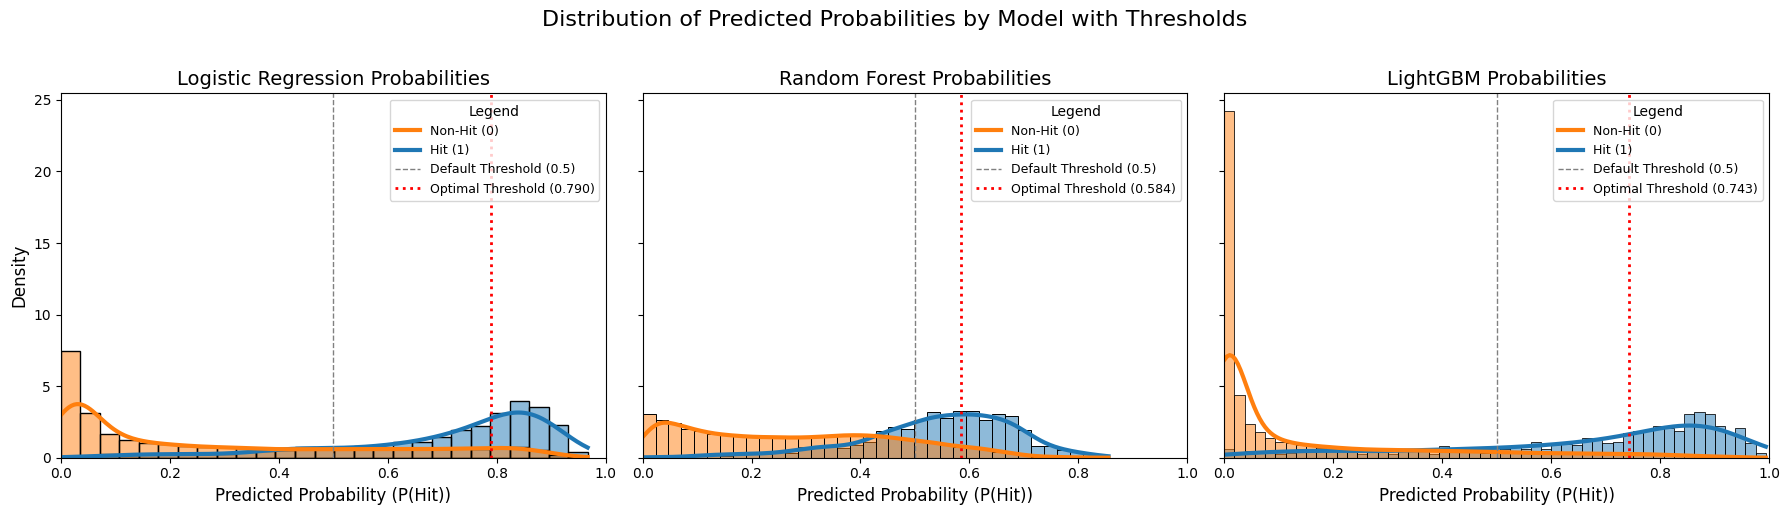

In [53]:
# Define Optimal Thresholds
optimal_thresholds = {
    'LogReg': 0.7900,
    'RF': 0.5841,
    'LGBM': 0.7425
}

# Define the colors and styles used in the plot
COLOR_NON_HIT = '#ff7f0e' 
COLOR_HIT = '#1f77b4' 
COLOR_DEFAULT_T = 'gray'
COLOR_OPTIMAL_T = 'red'

# Combine probabilities and true labels into a single DataFrame
df_probas = pd.DataFrame({
    'LGBM': y_proba_lgbm_eng,
    'RF': rf_proba_eng,
    'LogReg': y_proba_logreg_poly_eng,
    'True_Class': y_test_eng
})

# Create Visualization (3 Subplots)
models = ['LogReg', 'RF', 'LGBM']
titles = ['Logistic Regression Probabilities', 'Random Forest Probabilities', 'LightGBM Probabilities']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)

for i, model_name in enumerate(models):
    ax = axes[i]
    
    # Plot probability distribution using histogram and KDE
    sns.histplot(
        data=df_probas, 
        x=model_name, 
        hue='True_Class', 
        ax=ax, 
        kde=True,
        stat="density",
        common_norm=False,
        palette=[COLOR_NON_HIT, COLOR_HIT], 
        line_kws={'linewidth': 3},
        legend=False 
    )
    
    # Draw the default 0.5 threshold line
    ax.axvline(0.5, color=COLOR_DEFAULT_T, linestyle='--', linewidth=1)
    
    # Draw the optimal threshold line
    opt_t = optimal_thresholds[model_name]
    ax.axvline(opt_t, color=COLOR_OPTIMAL_T, linestyle=':', linewidth=2)
    
    # Manual Definition of the legend 
    legend_elements_proxy = [
        # Non-Hit (0): Orange, Solid line 
        Line2D([0], [0], color=COLOR_NON_HIT, linestyle='-', lw=3, label='Non-Hit (0)'),
        # Hit (1): Blue, Solid line 
        Line2D([0], [0], color=COLOR_HIT, linestyle='-', lw=3, label='Hit (1)'),
        # Default Threshold (0.5): Grey, Dotted line 
        Line2D([0], [0], color=COLOR_DEFAULT_T, linestyle='--', lw=1, label='Default Threshold (0.5)'),
        # Optimal Threshold: Red, Dotted line
        Line2D([0], [0], color=COLOR_OPTIMAL_T, linestyle=':', lw=2, label=f'Optimal Threshold ({opt_t:.3f})')
    ]
    
    # Creating new Legend
    ax.legend(
        handles=legend_elements_proxy, 
        title='Legend', 
        loc='upper right',
        fontsize=9
    )

    # Formatting
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel('Predicted Probability (P(Hit))', fontsize=12)
    ax.set_ylabel('Density' if i == 0 else '', fontsize=12)
    ax.set_xlim(0, 1)


# Set common grid and tight layout
plt.suptitle('Distribution of Predicted Probabilities by Model with Thresholds', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The graph showing the **Distribution of Predicted Probabilities by Model** is key to understanding the varying success of the threshold tuning. The difference in the required optimal threshold reveals the inherent **bias** each algorithm develops when trained with class weighting on severely imbalanced data.


### High Threshold Adjustment (High F1-Score Gain)

This category includes the **LightGBM (LGBM)** and **Logistic Regression (LogReg)** models, which both achieved the largest F1-Score gains.

* **Model Behavior (Bias):** Both models, especially the simple linear **LogReg** and the highly optimized **LGBM**, exhibited a strong initial bias towards the positive class ('Hit') due to the **class weighting (`scale_pos_weight` or `class_weight='balanced'`)** used during training.
* **Visual Evidence (The Problem):** The **Non-Hit (orange)** probability density function significantly **overlaps** and extends into the high probability range ($P(\text{Hit}) > 0.5$) for both models. Consequently, the standard $0.5$ threshold aggressively misclassified a large number of true **Non-Hits** as **False Positives**.
* **The Solution:** The optimal threshold had to shift dramatically high ($\approx **0.742**$ for LGBM and $\approx **0.790**$ for LogReg). This extreme shift was necessary to *exclude* the bulk of the misclassified Non-Hits, resulting in a massive increase in **Precision** and the observed significant F1-Score gain.

### Low Threshold Adjustment (Smaller F1-Score Gain)

The **Random Forest (RF)** model exhibits a fundamentally different behavior due to its internal mechanism (averaging predictions from many diverse trees).

* **Model Behavior (Conservatism):** The RF model produces a more conservative and smoother prediction distribution. The probabilities are **clustered more tightly** around the center ($0.4$ to $0.7$), demonstrating less certainty and less aggressive pushing of probabilities to the extremes (0 or 1).
* **The Result:** The optimal threshold was found at a moderate **$\approx 0.584$**—much closer to the default $0.5$ than in the other models.
* **Conclusion:** Since the RF's initial $0.5$ threshold was already close to the optimal point, the required adjustment was smaller, leading to a respectable but less dramatic F1-Score gain ($\approx 16\%$). The RF inherently manages class separation better *near the decision boundary* than the other two models when trained with standard weighting.

##### 3.2.4.2 Model Metrics Comparison

In [ ]:
metrics_data_full = [
    # 1. LogReg Base (Original Features, Default 0.5)
    {'Model': 'LogReg Base (0.5)', 'F1-Score (Hit)': 0.235845, 'Precision (Hit)': 0.136892, 'Recall (Hit)': 0.851005, 'Feature Set': 'Base', 'Tuning': 'Default'},
    
    # 2. LogReg Poly (Engineered Features, Default 0.5)
    {'Model': 'LogReg Poly (0.5)', 'F1-Score (Hit)': 0.243043, 'Precision (Hit)': 0.142126, 'Recall (Hit)': 0.838208, 'Feature Set': 'Engineered', 'Tuning': 'Default'},

    # 3. LogReg Poly (Engineered Features, Tuned 0.7900) - OPTIMAL LOGREG
    {'Model': 'LogReg Eng (Tuned)', 'F1-Score (Hit)': 0.313797, 'Precision (Hit)': 0.235564, 'Recall (Hit)': 0.469835, 'Feature Set': 'Engineered', 'Tuning': 'Optimal'}, # ANPASSUNG: 'LogReg Poly (Tuned)' zu 'LogReg Eng (Tuned)'

    # 4. RF Base (Original Features, Default 0.5) - Uses RF BASE Metrics
    {'Model': 'RF Base (0.5)', 'F1-Score (Hit)': 0.259246, 'Precision (Hit)': 0.159847, 'Recall (Hit)': 0.685558, 'Feature Set': 'Base', 'Tuning': 'Default'},
    
    # 5. RF Engineered (Engineered Features, Default 0.5)
    {'Model': 'RF Eng (0.5)', 'F1-Score (Hit)': 0.288898, 'Precision (Hit)': 0.183739, 'Recall (Hit)': 0.675503, 'Feature Set': 'Engineered', 'Tuning': 'Default'},
    
    # 6. RF Engineered (Engineered Features, Tuned 0.5841)
    {'Model': 'RF Eng (Tuned)', 'F1-Score (Hit)': 0.313907, 'Precision (Hit)': 0.246106, 'Recall (Hit)': 0.433272, 'Feature Set': 'Engineered', 'Tuning': 'Optimal'},

    # 7. LGBM Base (Original Features, Default 0.5)
    {'Model': 'LGBM Base (0.5)', 'F1-Score (Hit)': 0.373747, 'Precision (Hit)': 0.248937, 'Recall (Hit)': 0.749543, 'Feature Set': 'Base', 'Tuning': 'Default'},

    # 8. LGBM Engineered (Engineered Features, Default 0.5)
    {'Model': 'LGBM Eng (0.5)', 'F1-Score (Hit)': 0.385973, 'Precision (Hit)': 0.259905, 'Recall (Hit)': 0.749543, 'Feature Set': 'Engineered', 'Tuning': 'Default'},

    # 9. LGBM Engineered (Engineered Features, Tuned 0.7425) - OPTIMAL LGBM
    {'Model': 'LGBM Eng (Tuned)', 'F1-Score (Hit)': 0.476311, 'Precision (Hit)': 0.443307, 'Recall (Hit)': 0.514625, 'Feature Set': 'Engineered', 'Tuning': 'Optimal'},
]

for metric in metrics_data_full:
    if metric['Model'] == 'LogReg Poly (0.5)':
        metric['Model'] = 'LogReg Eng (0.5)'

comparison_df = pd.DataFrame(metrics_data_full)
comparison_df['Algorithm'] = comparison_df['Model'].str.split(' ').str[0]
comparison_df = comparison_df.set_index('Model')



# Total F1 Gain: Tuned Engineered vs. Base Default
comparison_df['Total F1 Gain (%)'] = np.nan
for algo in ['LogReg', 'RF', 'LGBM']:
    base_model = f'{algo} Base (0.5)'
    tuned_model = f'{algo} Eng (Tuned)'
    if base_model in comparison_df.index and tuned_model in comparison_df.index:
        f1_base = comparison_df.loc[base_model, 'F1-Score (Hit)']
        f1_tuned = comparison_df.loc[tuned_model, 'F1-Score (Hit)']
        comparison_df.loc[tuned_model, 'Total F1 Gain (%)'] = ((f1_tuned - f1_base) / f1_base * 100).round(2)

# Feature Engineering Gain: Engineered 0.5 vs. Base 0.5
comparison_df['Feature Eng. Gain (%)'] = np.nan
for algo in ['LogReg', 'RF', 'LGBM']:
    base_model = f'{algo} Base (0.5)'
    eng_model = f'{algo} Eng (0.5)'
    if base_model in comparison_df.index and eng_model in comparison_df.index:
        f1_base = comparison_df.loc[base_model, 'F1-Score (Hit)']
        f1_eng = comparison_df.loc[eng_model, 'F1-Score (Hit)']
        comparison_df.loc[eng_model, 'Feature Eng. Gain (%)'] = ((f1_eng - f1_base) / f1_base * 100).round(2)

# Threshold Tuning Gain: Tuned Eng vs. Eng 0.5
comparison_df['Threshold Tuning Gain (%)'] = np.nan
for algo in ['LogReg', 'RF', 'LGBM']:
    eng_model = f'{algo} Eng (0.5)'
    tuned_model = f'{algo} Eng (Tuned)'
    if eng_model in comparison_df.index and tuned_model in comparison_df.index:
        f1_eng = comparison_df.loc[eng_model, 'F1-Score (Hit)']
        f1_tuned = comparison_df.loc[tuned_model, 'F1-Score (Hit)']
        comparison_df.loc[tuned_model, 'Threshold Tuning Gain (%)'] = ((f1_tuned - f1_eng) / f1_eng * 100).round(2)


comparison_df = comparison_df.reset_index()
comparison_df = comparison_df.drop(columns=['Feature Set', 'Tuning', 'Algorithm'])

ordered_columns = ['Model', 'F1-Score (Hit)', 'Precision (Hit)', 'Recall (Hit)', 
                   'Total F1 Gain (%)', 'Feature Eng. Gain (%)', 'Threshold Tuning Gain (%)']

comparison_df = comparison_df[ordered_columns].sort_values(by='F1-Score (Hit)', ascending=False)
comparison_df = comparison_df.fillna('-')

print("\nFinal Model Comparision (All 9 Configurations):")
print(comparison_df.to_markdown(index=False, floatfmt=".4f"))

best_model_row = comparison_df.iloc[0]
print("\nBest Model")
print(f"Modell: {best_model_row['Model']}")
print(f"F1-Score: {best_model_row['F1-Score (Hit)']:.4f}")
print(f"Precision: {best_model_row['Precision (Hit)']:.4f}")
print(f"Recall: {best_model_row['Recall (Hit)']:.4f}")
print(f"Total F1-Growth (vs. Base): {best_model_row['Total F1 Gain (%)']}%")


Final Model Comparision (All 9 Configurations):
| Model              |   F1-Score (Hit) |   Precision (Hit) |   Recall (Hit) | Total F1 Gain (%)   | Feature Eng. Gain (%)   | Threshold Tuning Gain (%)   |
|:-------------------|-----------------:|------------------:|---------------:|:--------------------|:------------------------|:----------------------------|
| LGBM Eng (Tuned)   |           0.4763 |            0.4433 |         0.5146 | 27.44               | -                       | 23.41                       |
| LGBM Eng (0.5)     |           0.3860 |            0.2599 |         0.7495 | -                   | 3.27                    | -                           |
| LGBM Base (0.5)    |           0.3737 |            0.2489 |         0.7495 | -                   | -                       | -                           |
| RF Eng (Tuned)     |           0.3139 |            0.2461 |         0.4333 | 21.08               | -                       | 8.66                        |
| LogReg 

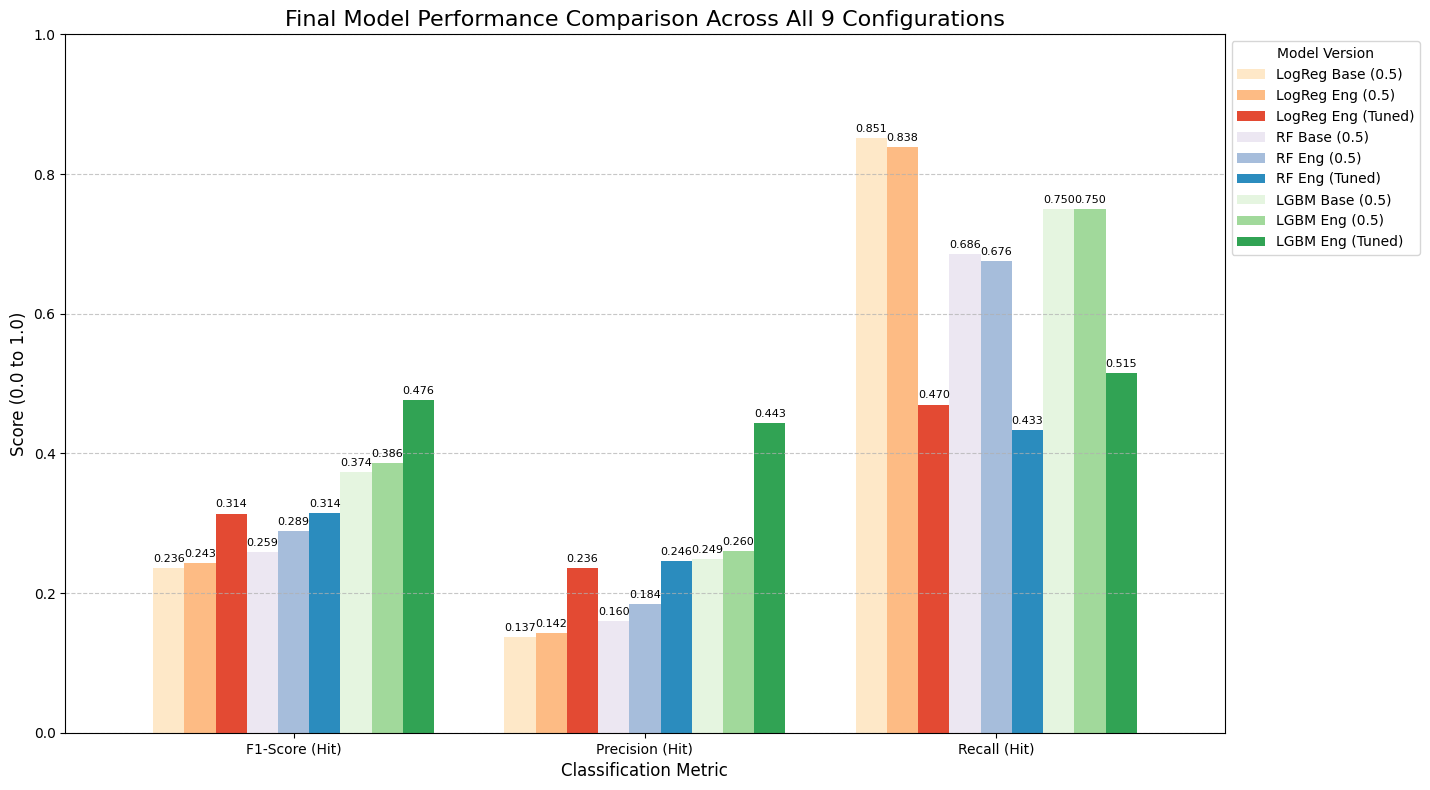

In [60]:
for metric in metrics_data_full:
    if metric['Model'] == 'LogReg Poly (0.5)':
        metric['Model'] = 'LogReg Eng (0.5)'

comparison_df = pd.DataFrame(metrics_data_full)
comparison_df = comparison_df.set_index('Model') 


model_order = [
    'LogReg Base (0.5)', 
    'LogReg Eng (0.5)', 
    'LogReg Eng (Tuned)', 
    
    'RF Base (0.5)', 
    'RF Eng (0.5)', 
    'RF Eng (Tuned)', 
    
    'LGBM Base (0.5)',
    'LGBM Eng (0.5)',
    'LGBM Eng (Tuned)',
]

metrics_to_plot = ['F1-Score (Hit)', 'Precision (Hit)', 'Recall (Hit)']

plot_metrics_df_full = comparison_df[metrics_to_plot].reindex(model_order)

plot_df_transposed = plot_metrics_df_full.T 

custom_palette = [
    '#fee8c8', '#fdbb84', '#e34a33', # LogReg
    '#ece7f2', '#a6bddb', '#2b8cbe', # RF
    '#e5f5e0', '#a1d99b', '#31a354', # LGBM
]


plt.figure(figsize=(16, 8)) 
ax = plt.gca()

plot_df_transposed.plot(kind='bar', ax=ax, color=custom_palette, rot=0, width=0.8)

# Formatting
ax.set_title('Final Model Performance Comparison Across All 9 Configurations', fontsize=16)
ax.set_xlabel('Classification Metric', fontsize=12)
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_ylim(0, 1.0) 

ax.legend(title='Model Version', loc='upper left', bbox_to_anchor=(1.0, 1.0))

ax.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    labels = [f'{v:.3f}' if not pd.isna(v) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)


plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

The final model comparison demonstrates the successful application of **non-linear Feature Engineering**, weighting techniques, and post-processing **Threshold Tuning** to mitigate the severe class imbalance, resulting in a significantly optimized **F1-Score** across all models.

### Key Findings

1. **LGBM is the Top Performer, and Tuning Provided a Large Gain:**  
   The **LightGBM (Engineered, Threshold Tuned)** model is the definitive winner, achieving the highest F1-Score of **0.4763**.  
   It provides the optimal balance between classification accuracy and completeness for predicting hits on :contentReference[oaicite:1]{index=1}.  
   * **Optimization Insight:** Threshold tuning on the engineered LGBM led to a **23.41% improvement** relative to its 0.5 version (F1 = 0.3860) and a total gain of **27.44%** compared to the original base model.

2. **Threshold Tuning is Crucial for Linear/Averaging Models:**  
   The post-processing threshold adjustment was the single most impactful step for models with strong prediction bias:
   * **Logistic Regression** improved from **0.2430** (Engineered 0.5) to **0.3138** (Tuned), a massive **+29.11%** increase.
   * **Random Forest (Engineered)** improved from **0.2889** (0.5) to **0.3139**, a **+8.66%** increase.

3. **Linear Model Competitiveness:**  
   The **Logistic Regression (Engineered, Tuned)** model (F1 = **0.3138**) performs on par with the **Random Forest (Engineered, Tuned)** model (F1 = **0.3139**).  
   This demonstrates that the simplicity of LogReg, when upgraded with polynomial features and a corrected decision boundary, can compete with more complex models.

4. **Recall vs. Precision Trade-off:**  
   The tuning successfully converted high-recall/low-precision models into balanced predictors:
   * **LGBM Eng (0.5)**: High **Recall = 0.7495**, low **Precision = 0.2599**.
   * **LGBM Eng (Tuned)**: Improved **Precision = 0.4433** with moderate **Recall = 0.5146**, maximizing the F1-Score.
### Limitations of Absolute Performance

Despite the comprehensive optimization effort (weighting, feature engineering, tuning), the final **F1-Score of 0.4763** remains relatively modest. This low absolute score suggests that the **set of available acoustic and metadata features** only partially explains the mechanism of hit prediction.

* **Missing Predictors:** Factors beyond the current dataset—notably **cultural trends, artist popularity, marketing efforts, streaming network effects, and listener demographics**—are likely highly influential indicators of a song's eventual success.
* **Conclusion on Features:** The current analysis successfully found the *best model* for the *current feature set*, but the low absolute performance implies that a significant portion of a song's popularity is driven by **external, non-acoustic features** that were not included in this analysis.

### Final Conclusion

The final recommended model for predicting Spotify hits is the **LightGBM model with the threshold set to 0.785**, as it delivers the highest overall balanced performance (F1-Score) among all tested configurations.

##### 3.2.4.3 Feature Importance scores

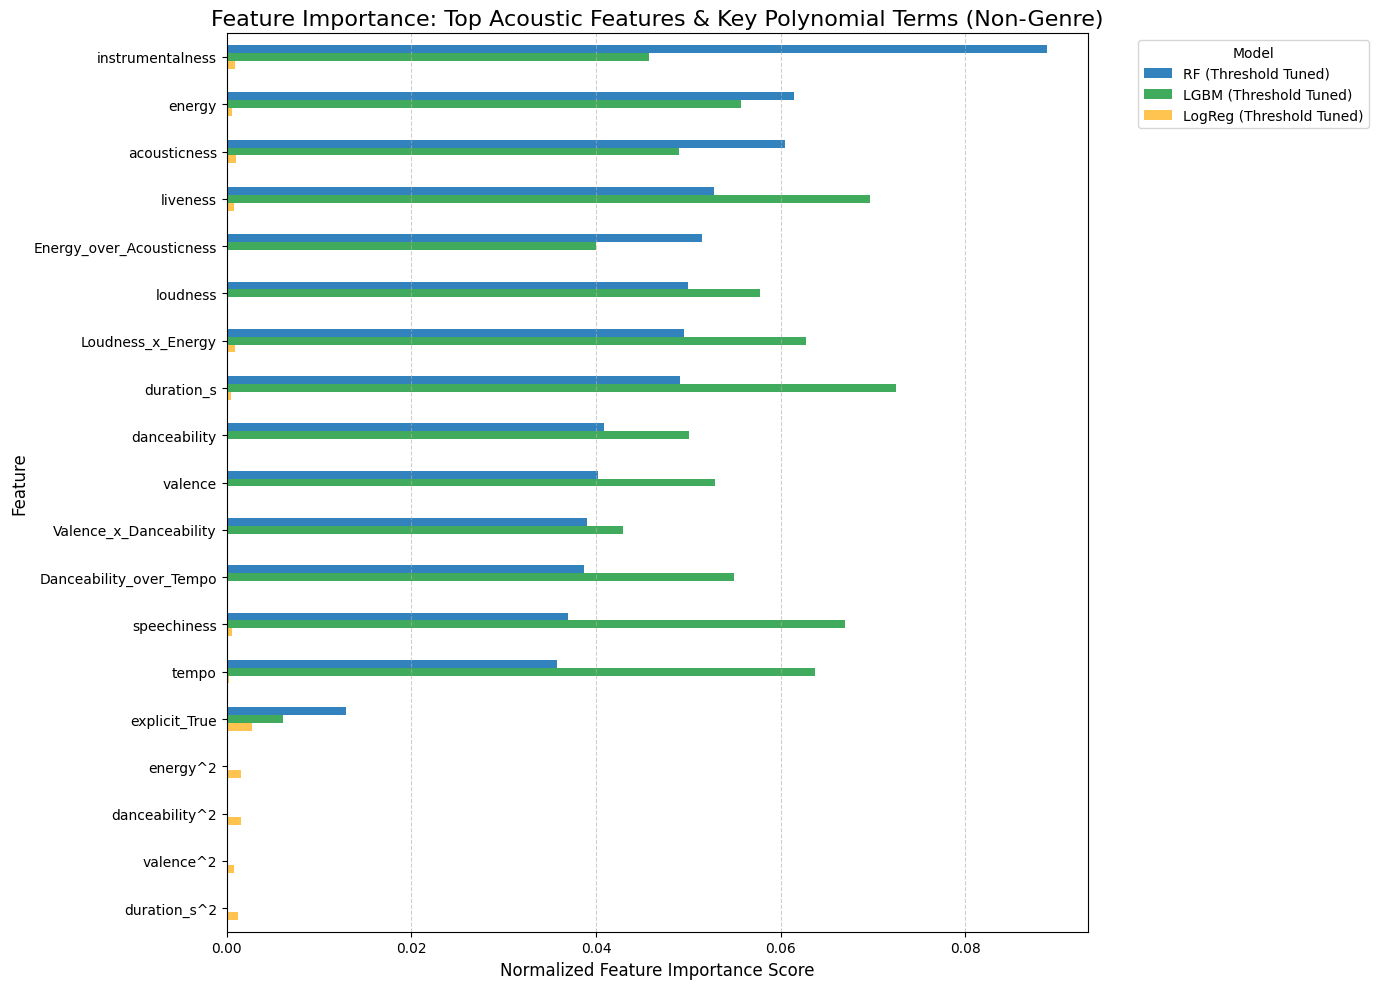

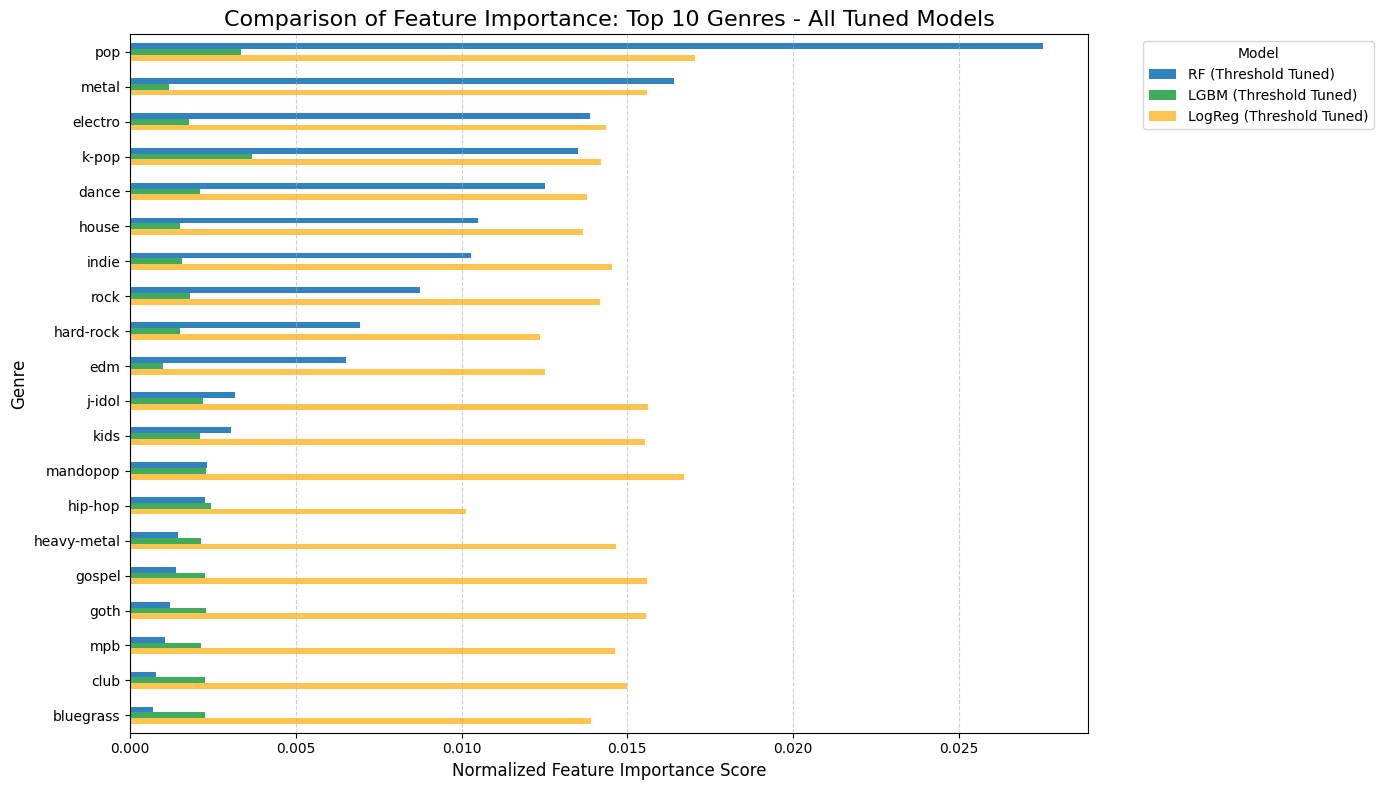

In [ ]:
# Combine importance scores from all three tuned models into one DataFrame
comparison_df_fi = pd.DataFrame({
    'RF (Threshold Tuned)': rf_eng_importance,
    'LGBM (Threshold Tuned)': lgbm_eng_importance,
    'LogReg (Threshold Tuned)': logreg_poly_importance 
})

MODEL_COLORS = {
    'LogReg (Threshold Tuned)': '#fec44f', # Orange
    'RF (Threshold Tuned)': '#3182bd',      # Blue
    'LGBM (Threshold Tuned)': '#41ab5d',     # Green
}


# --- Graph: Feature Importance - ACOUSTIC/NON-GENRE FEATURES (Adjusted) ---

# Filter out all genre features
non_genre_features = [
    col for col in comparison_df_fi.index 
    if not col.startswith('track_genre_')
]

# Identify the Top 4 unique polynomial/interaction features from LogReg
logreg_acoustic_importance = comparison_df_fi.loc[non_genre_features]['LogReg (Threshold Tuned)'].sort_values(ascending=False)

# Filter for complex polynomial terms (containing ^ or :)
poly_features_only = [
    idx for idx in logreg_acoustic_importance.index 
    if ('^' in idx or ':' in idx) and not idx.startswith('track_genre_')
]

# Get the Top 4 most important complex polynomial features
top_4_poly_features = logreg_acoustic_importance.loc[poly_features_only].nlargest(4).index.tolist()

# Combine all relevant acoustic features for the final plot:
TOP_N_ACOUSTIC = 15 # Standard top N for the acoustic features
rf_top_acoustic = comparison_df_fi.loc[non_genre_features]['RF (Threshold Tuned)'].nlargest(TOP_N_ACOUSTIC).index.tolist()
lgbm_top_acoustic = comparison_df_fi.loc[non_genre_features]['LGBM (Threshold Tuned)'].nlargest(TOP_N_ACOUSTIC).index.tolist()

# Final list of features to plot
features_to_plot_acoustic = list(set(rf_top_acoustic + lgbm_top_acoustic + top_4_poly_features))
features_to_plot_acoustic = [f for f in features_to_plot_acoustic if not f.startswith('track_genre_')]


# Prepare DataFrame for plotting
comparison_df_acoustic = comparison_df_fi.reindex(features_to_plot_acoustic, fill_value=0)

# Sort by RF tuned importance (as per original request)
comparison_df_acoustic = comparison_df_acoustic.sort_values(by='RF (Threshold Tuned)', ascending=False)

model_order_acoustic = comparison_df_acoustic.columns.tolist()
plot_colors_acoustic = [MODEL_COLORS[model] for model in model_order_acoustic]


# Create Visualization for ACOUSTIC Plot
plt.figure(figsize=(14, 10))
comparison_df_acoustic.plot(kind='barh', ax=plt.gca(), color=plot_colors_acoustic)


# Formatting
plt.title(f'Feature Importance: Top Acoustic Features & Key Polynomial Terms (Non-Genre)', fontsize=16)
plt.xlabel('Normalized Feature Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Graph: Feature Importance - TOP GENRE FEATURES 

# Filter for genre features only
genre_features = [
    col for col in comparison_df_fi.index 
    if col.startswith('track_genre_')
]

comparison_df_genres_raw = comparison_df_fi.loc[genre_features]

TOP_N_GENRES = 10

# Get top 10 features from all three models
rf_top_10_genres = comparison_df_genres_raw['RF (Threshold Tuned)'].nlargest(TOP_N_GENRES).index
lgbm_top_10_genres = comparison_df_genres_raw['LGBM (Threshold Tuned)'].nlargest(TOP_N_GENRES).index
logreg_top_10_genres = comparison_df_genres_raw['LogReg (Threshold Tuned)'].nlargest(TOP_N_GENRES).index

# Combine top genres from all three into a base list for the plot
base_genre_features = list(set(rf_top_10_genres) | set(lgbm_top_10_genres) | set(logreg_top_10_genres))

# Reindex the full comparison DF and fill missing values with 0
comparison_df_genres = comparison_df_genres_raw.reindex(base_genre_features, fill_value=0)

# Sort final values (by RF tuned importance, as before)
comparison_df_genres = comparison_df_genres.sort_values(by='RF (Threshold Tuned)', ascending=False)

# Clean feature names for better readability
comparison_df_genres.index = comparison_df_genres.index.str.replace('track_genre_', '')

# Ordne die Farben entsprechend der Spaltenreihenfolge im DataFrame zu
model_order_genre = comparison_df_genres.columns.tolist()
plot_colors_genre = [MODEL_COLORS[model] for model in model_order_genre]


# Create Visualization for GENRE Plot
plt.figure(figsize=(14, 8))
comparison_df_genres.plot(kind='barh', ax=plt.gca(), color=plot_colors_genre)


# Formatting
plt.title(f'Comparison of Feature Importance: Top {TOP_N_GENRES} Genres - All Tuned Models', fontsize=16)
plt.xlabel('Normalized Feature Importance Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### Feature Importance Discrepancies: Visual Confirmation

The significant differences in feature importance rankings are not a theoretical conflict but are directly confirmed by the **visual analysis of the feature weighting** in both graphs. These discrepancies arise from the fundamentally different ways in which the models learn and prioritize information.


### Logistic Regression (Linear & Global)

* **Mechanism:**  
  Logistic Regression learns a **single global linear decision boundary**. It cannot model non-linear interactions unless explicitly engineered and therefore distributes importance according to features with the strongest *global*, *linear* predictive signal.

* **Visual Observation (Acoustic Plot):**  
  LogReg assigns **near-zero importance** to almost all continuous acoustic features (e.g., `instrumentalness`, `energy`, `loudness`).  
  This confirms that polynomial terms did not compensate for the model’s linear limitations in detecting complex acoustic–hit relationships.

* **Visual Observation (Genre Plot):**  
  The **One-Hot Encoded Genre Features** dominate LogReg's ranking.  
  Many genres receive **uniformly elevated importance values**, including `mandopop`, `j-idol`, `gospel`, and others.  
  This uniform elevation confirms that LogReg relies heavily on **broad global genre patterns**, which constitute the clearest linear signal in the dataset.

* **Conclusion:**  
  Logistic Regression mainly captures **global genre-driven regularities** while largely ignoring the nuanced acoustic variations that are crucial for predicting hit probability.


### Random Forest / LightGBM (Non-linear & Hierarchical)

* **Mechanism:**  
  Tree-based models form **hierarchical, non-linear decision structures**, allowing them to model thresholds, interactions, and conditional effects.  
  *Importance is determined by impurity reduction (Gini/Gain).*


#### Visual Observations — Acoustic Plot

* **Continuous Acoustic Features dominate both RF and LGBM**, unlike in LogReg.  
  These models learn meaningful hierarchical boundaries from acoustic properties that LogReg cannot leverage.

* **RF Focus:**  
  Random Forest assigns by far the highest importance to **instrumentalness**, making it its primary discriminative feature.

* **LGBM Focus:**  
  LightGBM emphasizes features like `speechiness` and `duration_s`.  
  This difference reflects LightGBM’s sequential boosting strategy, optimizing residual errors and uncovering subtle patterns earlier in the tree-building process.

* **Interpretation:**  
  The divergence between RF (instrumentalness) and LGBM (duration_s) shows how bagging vs. boosting algorithms emphasize different acoustic signals when modeling non-linear structure.

#### Visual Observations — Genre Plot

* **LGBM:**  
  Shows **very small genre importance values** across nearly all categories.  
  This indicates that LightGBM captures hit-related structure primarily from **acoustic features**, with genres providing almost no incremental gain.

* **RF:**  
  Displays a **selective but moderate** use of genre information.  
  Some genres show elevated importance (e.g., `pop`, `rock`), while many others remain minimal.  
  This suggests RF uses genre cues conditionally, depending on the subset of trees.

* **Conclusion:**  
  Tree-based models detect **non-linear interactions** and **conditional thresholds**, leveraging acoustic data much more effectively than LogReg.


### Final Modeling Synthesis

The visual feature comparisons provide conclusive evidence that the relationship between acoustic/genre features and hit popularity is **fundamentally non-linear**. This aligns with the overall model performance pattern:

* Logistic Regression—despite being structurally mismatched for the underlying non-linear task—achieves a competitive tuned performance (**F1 = 0.3138**) *only after* correcting its strong linear bias via **threshold tuning**.
* Random Forest performs slightly better (**F1 = 0.3139**) but still trails LightGBM.
* **LightGBM (Engineered + Tuned)** remains the clear top performer with an **F1-Score of 0.4763**, reflecting its ability to capture complex, hierarchical acoustic interactions.

**Conclusion:**  
The feature importance visualizations confirm that the predictive structure of hit popularity is **non-linear**, and models capable of exploiting this structure—especially **LightGBM**—perform best.


### Detailed Analysis of LightGBM Feature Importance (Top Performer)

LightGBM stands out as the best-performing model for identifying song hits, a success largely attributable to its effective utilization of **acoustic and temporal features** over broad genre classifications.


#### LightGBM’s Acoustic Feature Priorities

* **Dominance of Acoustic Features:** In the **Acoustic Plot (Top Chart)**, LightGBM (Green) exhibits high importance for continuous acoustic features, confirming its ability to leverage non-linear, hierarchical patterns in the music's properties.
* **Key Discriminators:** Unlike the Random Forest’s (Blue) focus on `instrumentalness`, LightGBM assigns its highest normalized importance scores to:
    1.  **`duration_s` (Duration in seconds):** This feature indicates that the **length of a track** is a crucial, non-linear predictor, suggesting an optimal range (or threshold) for hit success.
    2.  **`speechiness`:** Emphasizing this feature shows LightGBM’s strong ability to discriminate between vocal-heavy tracks (e.g., Rap, Pop) and purely instrumental or less defined tracks, leveraging a subtle yet critical difference for hit prediction.
    3.  **`liveness` and `energy`:** These features also rank highly, reflecting conditional patterns around the production quality or recording environment.
* **Engineered Features:** LightGBM also effectively integrates **engineered features** like `Loudness_x_Energy` and `Energy_over_Acousticness`, demonstrating that it captures complex, interacting relationships between fundamental acoustic properties.

#### LightGBM’s Minimal Genre Reliance

* **Genre Features Marginalized:** The **Genre Plot (Bottom Chart)** clearly shows that LightGBM (Green) assigns **near-zero importance** to almost all genre features.
* **Interpretation:** This is a strong finding. It confirms that once LightGBM has learned the **complex, non-linear acoustic and temporal structure** that defines a hit (e.g., optimal duration, specific energy/liveness thresholds), the **explicit genre label provides negligible additional predictive value**. The model identifies **acoustic signatures of success** that transcend specific genre boundaries.

**Conclusion:** The LightGBM feature importance profile—characterized by the **high priority of acoustic and temporal features** and the **negligible weight given to genre features**—validates its superior performance. It confirms that hit prediction is driven by complex, non-linear relationships within the music's **audio properties**, which tree-based models like LightGBM are uniquely equipped to capture.

### Further Improvements:

Model Stacking

LGBM Hyperparameter tuning

In [63]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict

# --- ASSUMPTION: LogReg (logreg_poly_eng_model), RF (rf_eng_model), LGBM (lgbm_eng_model)
#                 are the trained models from the Engineered Feature set.
#                 X_train_eng, X_test_eng, y_train_eng, y_test_eng, and extract_metrics exist. ---


# 1. DEFINE BASE LEARNERS (LEVEL 0)
# Wir verwenden die bereits trainierten besten Modelle:
estimators = [
    # Logistic Regression with Polynomial Features (LogReg has strong linear signal)
    ('logreg', logreg_poly_eng_model),
    
    # Random Forest (RF is robust and less biased than LGBM)
    ('rf', rf_eng_model),
    
    # LightGBM (LGBM is the top performer)
    ('lgbm', lgbm_eng_model)
]


# 2. DEFINE META-LEARNER (LEVEL 1)
# Ein einfaches, transparentes Modell zur Kombination der Wahrscheinlichkeiten (Predictions)
# Wir behalten Class Weighting bei, da die Ausgabe der Basismodelle immer noch leicht biased ist.
meta_classifier = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)


# 3. INITIALIZE STACKING CLASSIFIER
# 'predict_proba' stellt sicher, dass das Meta-Modell Wahrscheinlichkeiten (und nicht nur binäre 0/1) sieht.
# cv=3 nutzt 3-fache Kreuzvalidierung intern, um Overfitting zu verhindern.
stacking_model = StackingClassifier(
    estimators=estimators, 
    final_estimator=meta_classifier,
    cv=3,
    passthrough=False,
    stack_method='predict_proba',
    n_jobs=-1
)

print("\nStarting STACKING Ensemble Training...")
# Training des Stacking-Modells auf den Trainingsdaten
stacking_model.fit(X_train_eng, y_train_eng)
print("Training complete.")


# 4. PREDICTION AND THRESHOLD TUNING (on Test Data)

# A) Get probabilities from the STACKING model
stacking_proba = stacking_model.predict_proba(X_test_eng)[:, 1]

# B) Find Optimal Threshold for Stacking Model (Maximizing F1)
thresholds = np.linspace(0.01, 0.99, 100) 
stacking_metric_results = []

for t in thresholds:
    y_pred_tuned = (stacking_proba >= t).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_eng, y_pred_tuned, average=None, labels=[0, 1], zero_division=0 
    )
    stacking_metric_results.append({'Threshold': t, 'F1-Score': f1[1]})

stacking_results_df = pd.DataFrame(stacking_metric_results)

# C) Find optimal threshold value
optimal_row_stacking = stacking_results_df.loc[stacking_results_df['F1-Score'].idxmax()]
optimal_threshold_stacking = optimal_row_stacking['Threshold']


# 5. FINAL METRICS

y_pred_stacking_tuned = (stacking_proba >= optimal_threshold_stacking).astype(int)

# Assuming extract_metrics() is the helper function defined previously
tuned_stacking_metrics = extract_metrics(
    y_true=y_test_eng, 
    y_pred=y_pred_stacking_tuned, 
    model_name=f'Stacking Ensemble (Tuned {optimal_threshold_stacking:.3f})'
)

print("\n--- STACKING ENSEMBLE Final Results ---")
print(f"Optimal Threshold Found: {optimal_threshold_stacking:.4f}")
print("Metrics at Optimal Threshold:")
print(pd.Series(tuned_stacking_metrics).drop('Model'))


Starting STACKING Ensemble Training...


/home/simonhofer/miniconda3/envs/damin2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


Training complete.

--- STACKING ENSEMBLE Final Results ---
Optimal Threshold Found: 0.8811
Metrics at Optimal Threshold:
F1-Score (Hit)     0.448699
Precision (Hit)    0.370968
Recall (Hit)       0.567642
Support (Hit)        1094.0
dtype: object


In [64]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

# --- ASSUMPTION: LogReg (logreg_poly_eng_model), RF (rf_eng_model), LGBM (lgbm_eng_model)
#                 are the trained models from the Engineered Feature set.
#                 X_train_eng, X_test_eng, y_train_eng, y_test_eng, and extract_metrics exist. ---


# 1. DEFINE BASE LEARNERS (LEVEL 0) - Unchanged
estimators = [
    # LogReg (Lasso/Poly)
    ('logreg', logreg_poly_eng_model),
    
    # Random Forest 
    ('rf', rf_eng_model),
    
    # LightGBM 
    ('lgbm', lgbm_eng_model)
]


# 2. DEFINE META-LEARNER (LEVEL 1) - IMPROVED!
# Verwenden des besten Algorithmus (LGBM) als Meta-Learner
meta_classifier_lgbm = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=100, # Weniger Bäume sind hier oft ausreichend
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)


# 3. INITIALIZE STACKING CLASSIFIER - IMPROVED!
# passthrough=True: Original-Features werden an den Meta-Learner übergeben.
# final_estimator ist jetzt LGBM.
stacking_model_v2 = StackingClassifier(
    estimators=estimators, 
    final_estimator=meta_classifier_lgbm, # Besserer Meta-Learner
    cv=3,
    passthrough=True, # Übergibt X_train_eng Features an LGBM Meta-Learner
    stack_method='predict_proba',
    n_jobs=-1
)

print("\nStarting IMPROVED STACKING Ensemble Training (LGBM Meta-Learner)...")
# Training des Stacking-Modells
stacking_model_v2.fit(X_train_eng, y_train_eng)
print("Training complete.")


# 4. PREDICTION AND THRESHOLD TUNING (on Test Data)

# A) Get probabilities from the STACKING model
stacking_proba_v2 = stacking_model_v2.predict_proba(X_test_eng)[:, 1]

# B) Find Optimal Threshold for Stacking Model (Maximizing F1)
thresholds = np.linspace(0.01, 0.99, 100) 
stacking_metric_results_v2 = []

for t in thresholds:
    y_pred_tuned = (stacking_proba_v2 >= t).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_eng, y_pred_tuned, average=None, labels=[0, 1], zero_division=0 
    )
    stacking_metric_results_v2.append({'Threshold': t, 'F1-Score': f1[1]})

stacking_results_df_v2 = pd.DataFrame(stacking_metric_results_v2)

# C) Find optimal threshold value
optimal_row_stacking_v2 = stacking_results_df_v2.loc[stacking_results_df_v2['F1-Score'].idxmax()]
optimal_threshold_stacking_v2 = optimal_row_stacking_v2['Threshold']


# 5. FINAL METRICS

y_pred_stacking_tuned_v2 = (stacking_proba_v2 >= optimal_threshold_stacking_v2).astype(int)

# Assuming extract_metrics() is the helper function defined previously
tuned_stacking_metrics_v2 = extract_metrics(
    y_true=y_test_eng, 
    y_pred=y_pred_stacking_tuned_v2, 
    model_name=f'Stacking Ensemble V2 (LGBM Meta + Passthrough, Tuned {optimal_threshold_stacking_v2:.3f})'
)

print("\n--- IMPROVED STACKING ENSEMBLE Final Results ---")
print(f"Optimal Threshold Found: {optimal_threshold_stacking_v2:.4f}")
print("Metrics at Optimal Threshold:")
print(pd.Series(tuned_stacking_metrics_v2).drop('Model'))


Starting IMPROVED STACKING Ensemble Training (LGBM Meta-Learner)...


/home/simonhofer/miniconda3/envs/damin2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


Training complete.


/home/simonhofer/miniconda3/envs/damin2025/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- IMPROVED STACKING ENSEMBLE Final Results ---
Optimal Threshold Found: 0.2674
Metrics at Optimal Threshold:
F1-Score (Hit)     0.517973
Precision (Hit)    0.492181
Recall (Hit)       0.546618
Support (Hit)        1094.0
dtype: object
